In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("=" * 70)
print("STEP 1: DATA LOADING AND CLEANING")
print("=" * 70)



STEP 1: DATA LOADING AND CLEANING


In [41]:
# Load the dataset
df = pd. read_csv('Post_AMI_Mortality_prediction_data.csv')

print("\n" + "-" * 70)
print("2. 1 INITIAL DATA OVERVIEW")
print("-" * 70)

print(f"\nDataset Shape: {df.shape}")
print(f"Number of patients: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Data Info ---")
print(df.info())



----------------------------------------------------------------------
2. 1 INITIAL DATA OVERVIEW
----------------------------------------------------------------------

Dataset Shape: (785, 18)
Number of patients: 785
Number of variables: 18

--- First 5 Rows ---
   Day30_mortality  Gender    Age  Killip_class  Diabetes Hypothension  \
0                0   0.000 48.391         1.000         0            0   
1                0   0.000 58.234         1.000         0            0   
2                0   0.000 35.250         1.000         0            0   
3                0   0.000 47.320         1.000         0            0   
4                0   0.000 81.688         2.000         0            0   

   Heart_rate  Anterior_infarct_location  Previous_myocardial_infarction  \
0           0                      0.000                               0   
1           1                      0.000                               0   
2           0                      0.000                     

In [42]:
# 3. COLUMN NAME CORRECTIONS
# =============================================================================

print("\n" + "-" * 70)
print("3. COLUMN NAME CORRECTIONS")
print("-" * 70)

# Store original column names for reference
original_columns = df.columns.tolist()

# Define column name corrections
column_corrections = {
    'Hypothension': 'Hypotension',      # Fix typo:  missing 'o'
    'Hyperthension': 'Hypertension'     # Fix typo:  extra 'h'
}

# Apply corrections
df = df.rename(columns=column_corrections)

# Verify corrections
print("\nColumn name corrections applied:")
for old_name, new_name in column_corrections. items():
    print(f"  '{old_name}' → '{new_name}'")

print("\n--- Updated Column Names ---")
print(df.columns.tolist())



----------------------------------------------------------------------
3. COLUMN NAME CORRECTIONS
----------------------------------------------------------------------

Column name corrections applied:
  'Hypothension' → 'Hypotension'
  'Hyperthension' → 'Hypertension'

--- Updated Column Names ---
['Day30_mortality', 'Gender', 'Age', 'Killip_class', 'Diabetes', 'Hypotension', 'Heart_rate', 'Anterior_infarct_location', 'Previous_myocardial_infarction', 'Height', 'Weight', 'Hypertension', 'Smoking', 'Hypercholesterolaemia', 'Previous_angina_pectoris', 'Family_history_of_MI', 'ST_elevation_leads', 'Time_To_Relief']


In [43]:
# =============================================================================
# 4. MISSING VALUE ANALYSIS
# =============================================================================

print("\n" + "-" * 70)
print("4. MISSING VALUE ANALYSIS")
print("-" * 70)

def analyze_missing_values(dataframe):
    """
    Comprehensive missing value analysis including special values.
    """
    missing_info = []

    for col in dataframe. columns:
        # Count standard NaN/None
        nan_count = dataframe[col]. isna().sum()

        # Count string representations of missing values
        if dataframe[col].dtype == 'object':
            string_missing = dataframe[col]. isin(['Unknown', 'NA', 'N/A', '', ' ']).sum()
        else:
            string_missing = 0

        # Count special invalid values
        special_missing = 0
        if col == 'Killip_class':
            # -1 is invalid for Killip class (should be 1-4)
            special_missing = (dataframe[col] == -1).sum()

        total_missing = nan_count + string_missing + special_missing

        missing_info.append({
            'Variable': col,
            'NaN_Count': nan_count,
            'String_Missing':  string_missing,
            'Special_Invalid': special_missing,
            'Total_Missing': total_missing,
            'Missing_Percent': round(total_missing / len(dataframe) * 100, 2)
        })

    return pd.DataFrame(missing_info)

# Analyze missing values
missing_df = analyze_missing_values(df)
missing_with_values = missing_df[missing_df['Total_Missing'] > 0]

print("\n--- Variables with Missing Values ---")
if len(missing_with_values) > 0:
    print(missing_with_values. to_string(index=False))
else:
    print("No missing values detected.")

# Show unique values for problematic columns
print("\n--- Unique Values in 'Hypotension' (object type) ---")
print(df['Hypotension'].unique())

print("\n--- Unique Values in 'Killip_class' ---")
print(sorted(df['Killip_class'].dropna().unique()))




----------------------------------------------------------------------
4. MISSING VALUE ANALYSIS
----------------------------------------------------------------------

--- Variables with Missing Values ---
                 Variable  NaN_Count  String_Missing  Special_Invalid  Total_Missing  Missing_Percent
                   Gender          2               0                0              2            0.250
                      Age          1               0                0              1            0.130
             Killip_class          1               0               14             15            1.910
              Hypotension          1               3                0              4            0.510
Anterior_infarct_location          1               0                0              1            0.130
                   Height          1               0                0              1            0.130

--- Unique Values in 'Hypotension' (object type) ---
['0' 'Unknown' '1' nan]


In [44]:
# =============================================================================
# 5. DATA QUALITY CHECKS
# =============================================================================

print("\n" + "-" * 70)
print("5. DATA QUALITY CHECKS")
print("-" * 70)

# 5.1 Check for outliers in Height
print("\n--- Height Distribution Check ---")
print(f"Height - Min: {df['Height'].min()}, Max: {df['Height'].max()}")
print(f"Height - Mean: {df['Height'].mean():.2f}, Median: {df['Height'].median():.2f}")

# Identify problematic height values
problematic_heights = df[(df['Height'] < 100) | (df['Height'] > 250)]
if len(problematic_heights) > 0:
    print(f"\nProblematic Height values found ({len(problematic_heights)} rows):")
    print(problematic_heights[['Height']].to_string())

# 5.2 Check Weight distribution
print("\n--- Weight Distribution Check ---")
print(f"Weight - Min:  {df['Weight']. min()}, Max: {df['Weight']. max()}")
print(f"Weight - Mean: {df['Weight'].mean():.2f}, Median: {df['Weight'].median():.2f}")

# 5.3 Check Age distribution
print("\n--- Age Distribution Check ---")
print(f"Age - Min:  {df['Age']. min()}, Max: {df['Age']. max()}")
print(f"Age - Mean: {df['Age'].mean():.2f}, Median: {df['Age'].median():.2f}")

# 5.4 Check Killip class distribution
print("\n--- Killip Class Distribution ---")
print(df['Killip_class'].value_counts(dropna=False).sort_index())




----------------------------------------------------------------------
5. DATA QUALITY CHECKS
----------------------------------------------------------------------

--- Height Distribution Check ---
Height - Min: 1.75, Max: 1690.0
Height - Mean: 170.95, Median: 170.00

Problematic Height values found (2 rows):
      Height
338 1690.000
419    1.750

--- Weight Distribution Check ---
Weight - Min:  40.0, Max: 128.0
Weight - Mean: 75.24, Median: 75.00

--- Age Distribution Check ---
Age - Min:  28.367, Max: 86.0
Age - Mean: 61.82, Median: 62.84

--- Killip Class Distribution ---
Killip_class
-1.000     14
1.000     603
2.000     146
3.000      20
4.000       1
NaN         1
Name: count, dtype: int64


In [45]:
# =============================================================================
# 6. DATA CLEANING - FIX ISSUES
# =============================================================================

print("\n" + "-" * 70)
print("6. DATA CLEANING - FIXING ISSUES")
print("-" * 70)

# Create a copy for cleaning
df_clean = df.copy()

# Track changes
changes_log = []

# -----------------------------------------------------------------------------
# 6.1 Fix Height Data Entry Errors
# -----------------------------------------------------------------------------
print("\n6.1 Fixing Height Data Entry Errors...")

# Fix values > 250 (likely entered as mm instead of cm, e.g., 1690 → 169)
mask_height_large = df_clean['Height'] > 250
n_fixed_large = mask_height_large. sum()
if n_fixed_large > 0:
    original_values = df_clean. loc[mask_height_large, 'Height'].values
    df_clean.loc[mask_height_large, 'Height'] = df_clean.loc[mask_height_large, 'Height'] / 10
    corrected_values = df_clean. loc[mask_height_large, 'Height'].values
    print(f"  Fixed {n_fixed_large} large height values (divided by 10):")
    for orig, corr in zip(original_values, corrected_values):
        print(f"    {orig} → {corr}")
    changes_log.append(f"Height > 250: {n_fixed_large} values corrected (÷10)")

# Fix values < 100 (likely entered in meters, e.g., 1.75 → 175)
mask_height_small = df_clean['Height'] < 100
n_fixed_small = mask_height_small.sum()
if n_fixed_small > 0:
    original_values = df_clean.loc[mask_height_small, 'Height'].values
    df_clean. loc[mask_height_small, 'Height'] = df_clean.loc[mask_height_small, 'Height'] * 100
    corrected_values = df_clean.loc[mask_height_small, 'Height']. values
    print(f"  Fixed {n_fixed_small} small height values (multiplied by 100):")
    for orig, corr in zip(original_values, corrected_values):
        print(f"    {orig} → {corr}")
    changes_log.append(f"Height < 100: {n_fixed_small} values corrected (×100)")

print(f"  Height range after fixing: {df_clean['Height'].min():.1f} - {df_clean['Height'].max():.1f}")

# -----------------------------------------------------------------------------
# 6.2 Fix Hypotension Column (convert 'Unknown' to NaN)
# -----------------------------------------------------------------------------
print("\n6.2 Fixing Hypotension Column...")

# Count 'Unknown' values before conversion
unknown_count = (df_clean['Hypotension'] == 'Unknown').sum()
print(f"  'Unknown' values found: {unknown_count}")

# Replace 'Unknown' with NaN
df_clean['Hypotension'] = df_clean['Hypotension'].replace('Unknown', np.nan)

# Convert to numeric
df_clean['Hypotension'] = pd.to_numeric(df_clean['Hypotension'], errors='coerce')

print(f"  Converted 'Unknown' to NaN and column to numeric type")
changes_log.append(f"Hypotension:  {unknown_count} 'Unknown' values → NaN")

# -----------------------------------------------------------------------------
# 6.3 Fix Killip_class Invalid Values (-1 → NaN)
# -----------------------------------------------------------------------------
print("\n6.3 Fixing Killip_class Invalid Values...")

# Count -1 values
invalid_killip = (df_clean['Killip_class'] == -1).sum()
print(f"  Invalid values (-1) found: {invalid_killip}")

# Replace -1 with NaN
df_clean['Killip_class'] = df_clean['Killip_class'].replace(-1, np.nan)

print(f"  Replaced -1 with NaN")
changes_log. append(f"Killip_class:  {invalid_killip} invalid (-1) values → NaN")

# -----------------------------------------------------------------------------
# 6.4 Summary of Missing Values After Initial Cleaning
# -----------------------------------------------------------------------------
print("\n6.4 Missing Values After Initial Cleaning...")

missing_after = df_clean.isna().sum()
missing_after = missing_after[missing_after > 0]
print("\nVariables with missing values:")
for col, count in missing_after.items():
    pct = count / len(df_clean) * 100
    print(f"  {col}:  {count} ({pct:.2f}%)")



----------------------------------------------------------------------
6. DATA CLEANING - FIXING ISSUES
----------------------------------------------------------------------

6.1 Fixing Height Data Entry Errors...
  Fixed 1 large height values (divided by 10):
    1690.0 → 169.0
  Fixed 1 small height values (multiplied by 100):
    1.75 → 175.0
  Height range after fixing: 141.3 - 197.0

6.2 Fixing Hypotension Column...
  'Unknown' values found: 3
  Converted 'Unknown' to NaN and column to numeric type

6.3 Fixing Killip_class Invalid Values...
  Invalid values (-1) found: 14
  Replaced -1 with NaN

6.4 Missing Values After Initial Cleaning...

Variables with missing values:
  Gender:  2 (0.25%)
  Age:  1 (0.13%)
  Killip_class:  15 (1.91%)
  Hypotension:  4 (0.51%)
  Anterior_infarct_location:  1 (0.13%)
  Height:  1 (0.13%)


In [46]:
# =============================================================================
# 7. MISSING VALUE IMPUTATION
# =============================================================================

print("\n" + "-" * 70)
print("7. MISSING VALUE IMPUTATION")
print("-" * 70)

# Define imputation strategy based on variable type and clinical relevance
print("\nImputation Strategy:")
print("  - Continuous variables:  Median imputation (robust to outliers)")
print("  - Categorical/Binary variables: Mode imputation (most frequent value)")
print("\nJustification:  Low missing rate (<2%) allows simple imputation without")
print("significant bias.  MAR assumption is reasonable given data collection context.")

# -----------------------------------------------------------------------------
# 7.1 Impute Continuous Variables with Median
# -----------------------------------------------------------------------------
print("\n7.1 Imputing Continuous Variables (Median)...")

continuous_vars = ['Age', 'Height']

for var in continuous_vars:
    missing_count = df_clean[var].isna().sum()
    if missing_count > 0:
        median_value = df_clean[var].median()
        df_clean[var].fillna(median_value, inplace=True)
        print(f"  {var}: {missing_count} missing → imputed with median = {median_value:.2f}")
        changes_log.append(f"{var}:  {missing_count} values imputed with median ({median_value:.2f})")

# -----------------------------------------------------------------------------
# 7.2 Impute Categorical/Binary Variables with Mode
# -----------------------------------------------------------------------------
print("\n7.2 Imputing Categorical/Binary Variables (Mode)...")

categorical_vars = ['Gender', 'Killip_class', 'Hypotension', 'Anterior_infarct_location']

for var in categorical_vars:
    missing_count = df_clean[var].isna().sum()
    if missing_count > 0:
        mode_value = df_clean[var].mode()[0]
        df_clean[var]. fillna(mode_value, inplace=True)
        print(f"  {var}: {missing_count} missing → imputed with mode = {mode_value}")
        changes_log. append(f"{var}: {missing_count} values imputed with mode ({mode_value})")

# -----------------------------------------------------------------------------
# 7.3 Verify No Missing Values Remain
# -----------------------------------------------------------------------------
print("\n7.3 Verification - Missing Values After Imputation...")

total_missing = df_clean.isna().sum().sum()
print(f"  Total missing values remaining: {total_missing}")

if total_missing == 0:
    print("  ✓ All missing values successfully handled!")
else:
    print("  ✗ Warning: Some missing values remain!")
    print(df_clean. isna().sum()[df_clean.isna().sum() > 0])




----------------------------------------------------------------------
7. MISSING VALUE IMPUTATION
----------------------------------------------------------------------

Imputation Strategy:
  - Continuous variables:  Median imputation (robust to outliers)
  - Categorical/Binary variables: Mode imputation (most frequent value)

Justification:  Low missing rate (<2%) allows simple imputation without
significant bias.  MAR assumption is reasonable given data collection context.

7.1 Imputing Continuous Variables (Median)...
  Age: 1 missing → imputed with median = 62.84
  Height: 1 missing → imputed with median = 170.00

7.2 Imputing Categorical/Binary Variables (Mode)...
  Gender: 2 missing → imputed with mode = 0.0
  Killip_class: 15 missing → imputed with mode = 1.0
  Hypotension: 4 missing → imputed with mode = 0.0
  Anterior_infarct_location: 1 missing → imputed with mode = 0.0

7.3 Verification - Missing Values After Imputation...
  Total missing values remaining: 0
  ✓ All missi

In [47]:
# =============================================================================
# 8. DATA TYPE CORRECTIONS
# =============================================================================

print("\n" + "-" * 70)
print("8. DATA TYPE CORRECTIONS")
print("-" * 70)

# Define expected data types
binary_vars = [
    'Day30_mortality', 'Gender', 'Diabetes', 'Hypotension',
    'Heart_rate', 'Anterior_infarct_location',
    'Previous_myocardial_infarction', 'Hypertension',
    'Hypercholesterolaemia', 'Previous_angina_pectoris',
    'Family_history_of_MI', 'Time_To_Relief'
]

ordinal_vars = ['Killip_class', 'Smoking']
continuous_vars = ['Age', 'Height', 'Weight', 'ST_elevation_leads']

# Convert binary variables to int
print("\nConverting binary variables to int...")
for var in binary_vars:
    if var in df_clean.columns:
        df_clean[var] = df_clean[var].astype(int)

# Convert ordinal variables to int
print("Converting ordinal variables to int...")
for var in ordinal_vars:
    if var in df_clean.columns:
        df_clean[var] = df_clean[var]. astype(int)

# Keep continuous as float
print("Keeping continuous variables as float...")
for var in continuous_vars:
    if var in df_clean.columns:
        df_clean[var] = df_clean[var]. astype(float)

print("\n--- Updated Data Types ---")
print(df_clean. dtypes)




----------------------------------------------------------------------
8. DATA TYPE CORRECTIONS
----------------------------------------------------------------------

Converting binary variables to int...
Converting ordinal variables to int...
Keeping continuous variables as float...

--- Updated Data Types ---
Day30_mortality                     int64
Gender                              int64
Age                               float64
Killip_class                        int64
Diabetes                            int64
Hypotension                         int64
Heart_rate                          int64
Anterior_infarct_location           int64
Previous_myocardial_infarction      int64
Height                            float64
Weight                            float64
Hypertension                        int64
Smoking                             int64
Hypercholesterolaemia               int64
Previous_angina_pectoris            int64
Family_history_of_MI                int64
ST_elevation_

In [48]:
# =============================================================================
# 9. FINAL VALIDATION
# =============================================================================

print("\n" + "-" * 70)
print("9. FINAL VALIDATION")
print("-" * 70)

# 9.1 Shape check
print(f"\n9.1 Dataset Shape: {df_clean.shape}")

# 9.2 Missing values check
print(f"\n9.2 Total Missing Values: {df_clean.isna().sum().sum()}")

# 9.3 Value ranges for key variables
print("\n9.3 Value Ranges for Key Variables:")
print(f"  Age: {df_clean['Age'].min():.1f} - {df_clean['Age'].max():.1f}")
print(f"  Height: {df_clean['Height'].min():.1f} - {df_clean['Height'].max():.1f}")
print(f"  Weight: {df_clean['Weight'].min():.1f} - {df_clean['Weight'].max():.1f}")
print(f"  Killip_class: {df_clean['Killip_class']. min()} - {df_clean['Killip_class'].max()}")
print(f"  ST_elevation_leads:  {df_clean['ST_elevation_leads'].min()} - {df_clean['ST_elevation_leads'].max()}")

# 9.4 Outcome distribution
print("\n9.4 Outcome Distribution:")
outcome_counts = df_clean['Day30_mortality'].value_counts()
print(f"  Survived (0): {outcome_counts[0]} ({outcome_counts[0]/len(df_clean)*100:.1f}%)")
print(f"  Died (1): {outcome_counts[1]} ({outcome_counts[1]/len(df_clean)*100:.1f}%)")
print(f"  Imbalance Ratio: {outcome_counts[0]/outcome_counts[1]:.1f}: 1")

# 9.5 Binary variables validation
print("\n9.5 Binary Variables Validation (should only have 0 and 1):")
for var in binary_vars:
    if var in df_clean. columns:
        unique_vals = sorted(df_clean[var].unique())
        status = "✓" if unique_vals == [0, 1] else "✗"
        print(f"  {status} {var}: {unique_vals}")

# 9.6 Killip class validation (should be 1-4)
print("\n9.6 Killip Class Validation (should be 1-4):")
killip_vals = sorted(df_clean['Killip_class'].unique())
status = "✓" if all(v in [1, 2, 3, 4] for v in killip_vals) else "✗"
print(f"  {status} Killip_class: {killip_vals}")

# 9.7 Smoking validation (should be 1-3)
print("\n9.7 Smoking Validation (should be 1=never, 2=ex, 3=current):")
smoking_vals = sorted(df_clean['Smoking'].unique())
status = "✓" if all(v in [1, 2, 3] for v in smoking_vals) else "✗"
print(f"  {status} Smoking: {smoking_vals}")




----------------------------------------------------------------------
9. FINAL VALIDATION
----------------------------------------------------------------------

9.1 Dataset Shape: (785, 18)

9.2 Total Missing Values: 0

9.3 Value Ranges for Key Variables:
  Age: 28.4 - 86.0
  Height: 141.3 - 197.0
  Weight: 40.0 - 128.0
  Killip_class: 1 - 4
  ST_elevation_leads:  0.0 - 10.0

9.4 Outcome Distribution:
  Survived (0): 733 (93.4%)
  Died (1): 52 (6.6%)
  Imbalance Ratio: 14.1: 1

9.5 Binary Variables Validation (should only have 0 and 1):
  ✓ Day30_mortality: [np.int64(0), np.int64(1)]
  ✓ Gender: [np.int64(0), np.int64(1)]
  ✓ Diabetes: [np.int64(0), np.int64(1)]
  ✓ Hypotension: [np.int64(0), np.int64(1)]
  ✓ Heart_rate: [np.int64(0), np.int64(1)]
  ✓ Anterior_infarct_location: [np.int64(0), np.int64(1)]
  ✓ Previous_myocardial_infarction: [np.int64(0), np.int64(1)]
  ✓ Hypertension: [np.int64(0), np.int64(1)]
  ✓ Hypercholesterolaemia: [np.int64(0), np.int64(1)]
  ✓ Previous_angina

In [49]:
# =============================================================================
# 10. SUMMARY OF CHANGES
# =============================================================================

print("\n" + "-" * 70)
print("10. SUMMARY OF ALL CHANGES")
print("-" * 70)

print("\n--- Column Renaming ---")
for old_name, new_name in column_corrections.items():
    print(f"  • '{old_name}' → '{new_name}'")

print("\n--- Data Corrections & Imputations ---")
for change in changes_log:
    print(f"  • {change}")

print("\n--- Final Dataset Summary ---")
print(f"  • Rows: {df_clean.shape[0]}")
print(f"  • Columns: {df_clean.shape[1]}")
print(f"  • Missing values: {df_clean.isna().sum().sum()}")
print(f"  • Memory usage: {df_clean.memory_usage(deep=True).sum() / 1024:.2f} KB")



----------------------------------------------------------------------
10. SUMMARY OF ALL CHANGES
----------------------------------------------------------------------

--- Column Renaming ---
  • 'Hypothension' → 'Hypotension'
  • 'Hyperthension' → 'Hypertension'

--- Data Corrections & Imputations ---
  • Height > 250: 1 values corrected (÷10)
  • Height < 100: 1 values corrected (×100)
  • Hypotension:  3 'Unknown' values → NaN
  • Killip_class:  14 invalid (-1) values → NaN
  • Age:  1 values imputed with median (62.84)
  • Height:  1 values imputed with median (170.00)
  • Gender: 2 values imputed with mode (0.0)
  • Killip_class: 15 values imputed with mode (1.0)
  • Hypotension: 4 values imputed with mode (0.0)
  • Anterior_infarct_location: 1 values imputed with mode (0.0)

--- Final Dataset Summary ---
  • Rows: 785
  • Columns: 18
  • Missing values: 0
  • Memory usage: 110.52 KB


In [50]:
# =============================================================================
# 11. SAVE CLEANED DATA
# =============================================================================

print("\n" + "-" * 70)
print("11. SAVE CLEANED DATA")
print("-" * 70)

# Save cleaned dataset
output_filename = 'ISDS_data_cleaned.csv'
df_clean. to_csv(output_filename, index=False)
print(f"\nCleaned dataset saved to: '{output_filename}'")

# Display final dataset info
print("\n--- Final Dataset Head ---")
print(df_clean.head())

print("\n--- Final Dataset Info ---")
print(df_clean.info())




----------------------------------------------------------------------
11. SAVE CLEANED DATA
----------------------------------------------------------------------

Cleaned dataset saved to: 'ISDS_data_cleaned.csv'

--- Final Dataset Head ---
   Day30_mortality  Gender    Age  Killip_class  Diabetes  Hypotension  \
0                0       0 48.391             1         0            0   
1                0       0 58.234             1         0            0   
2                0       0 35.250             1         0            0   
3                0       0 47.320             1         0            0   
4                0       0 81.688             2         0            0   

   Heart_rate  Anterior_infarct_location  Previous_myocardial_infarction  \
0           0                          0                               0   
1           1                          0                               0   
2           0                          0                               0   
3      


----------------------------------------------------------------------
12. DATA CLEANING VISUALIZATION
----------------------------------------------------------------------


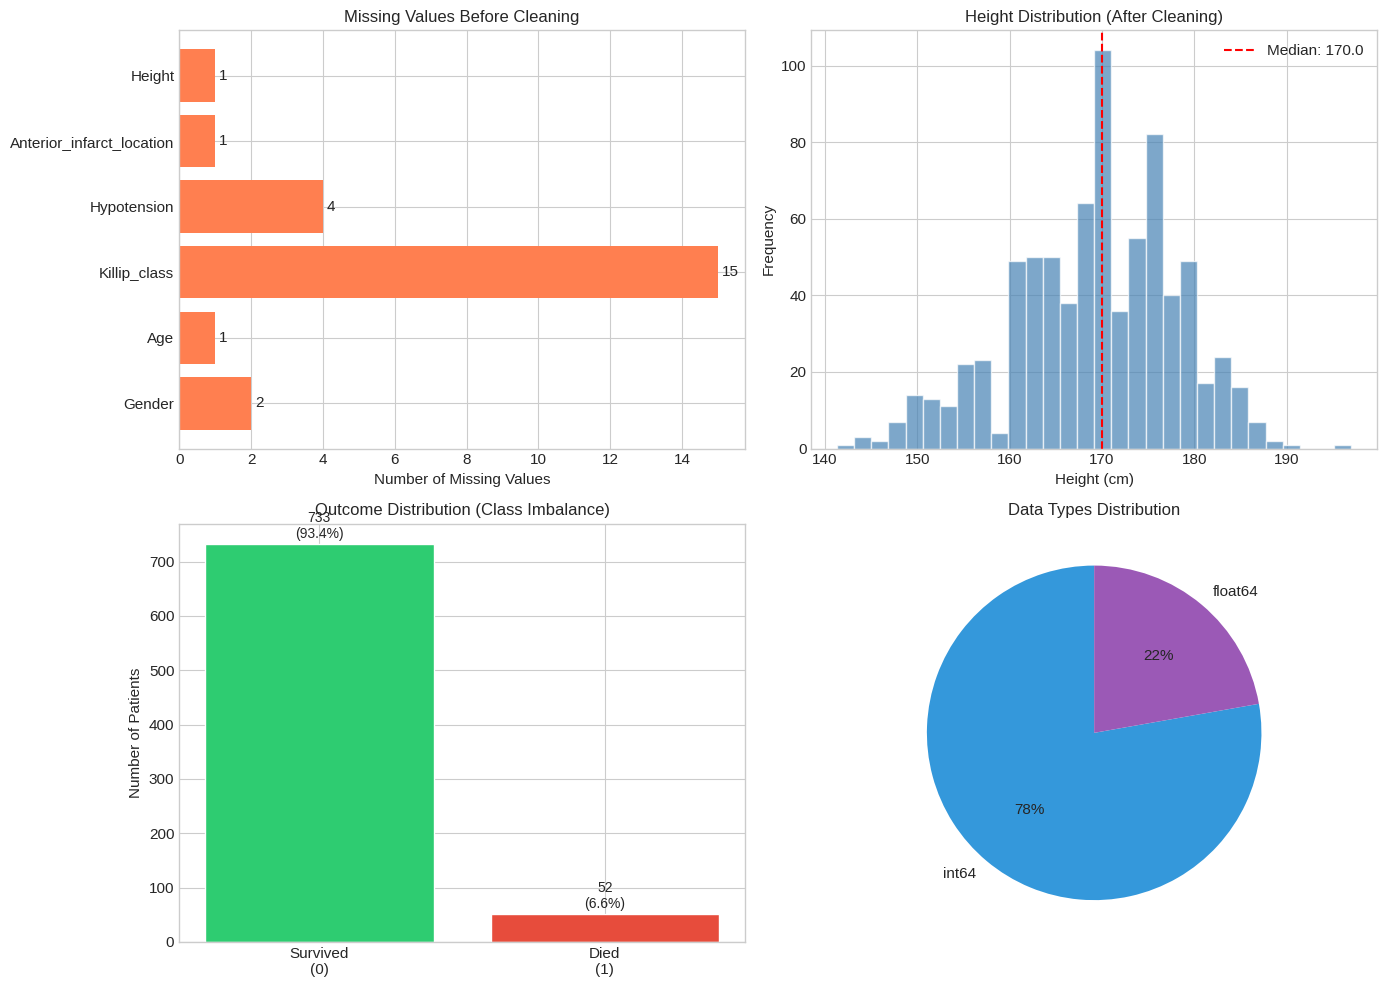


Visualization saved to: 'data_cleaning_report.png'

DATA CLEANING COMPLETE!


In [51]:
# =============================================================================
# 12. CREATE CLEANING REPORT VISUALIZATION
# =============================================================================

print("\n" + "-" * 70)
print("12. DATA CLEANING VISUALIZATION")
print("-" * 70)

fig, axes = plt. subplots(2, 2, figsize=(14, 10))

# 12.1 Missing values before cleaning
ax1 = axes[0, 0]
missing_before = missing_df[missing_df['Total_Missing'] > 0]
if len(missing_before) > 0:
    bars = ax1.barh(missing_before['Variable'], missing_before['Total_Missing'], color='coral')
    ax1.set_xlabel('Number of Missing Values')
    ax1.set_title('Missing Values Before Cleaning')
    ax1.bar_label(bars, padding=3)
else:
    ax1.text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('Missing Values Before Cleaning')

# 12.2 Height distribution after cleaning
ax2 = axes[0, 1]
ax2.hist(df_clean['Height'], bins=30, color='steelblue', edgecolor='white', alpha=0.7)
ax2.axvline(df_clean['Height'].median(), color='red', linestyle='--', label=f"Median: {df_clean['Height']. median():.1f}")
ax2.set_xlabel('Height (cm)')
ax2.set_ylabel('Frequency')
ax2.set_title('Height Distribution (After Cleaning)')
ax2.legend()

# 12.3 Outcome distribution
ax3 = axes[1, 0]
outcome_labels = ['Survived\n(0)', 'Died\n(1)']
outcome_values = [outcome_counts[0], outcome_counts[1]]
colors = ['#2ecc71', '#e74c3c']
bars = ax3.bar(outcome_labels, outcome_values, color=colors, edgecolor='white')
ax3.set_ylabel('Number of Patients')
ax3.set_title('Outcome Distribution (Class Imbalance)')
for bar, val in zip(bars, outcome_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val}\n({val/len(df_clean)*100:.1f}%)', ha='center', fontsize=10)

# 12.4 Data types summary
ax4 = axes[1, 1]
dtype_counts = df_clean. dtypes.value_counts()
ax4.pie(dtype_counts. values, labels=dtype_counts.index. astype(str), autopct='%1.0f%%',
        colors=['#3498db', '#9b59b6', '#1abc9c'], startangle=90)
ax4.set_title('Data Types Distribution')

plt.tight_layout()
plt.savefig('data_cleaning_report.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved to: 'data_cleaning_report.png'")

print("\n" + "=" * 70)
print("DATA CLEANING COMPLETE!")
print("=" * 70)

STEP 2: EXPLORATORY DATA ANALYSIS

----------------------------------------------------------------------
2.  LOAD CLEANED DATA
----------------------------------------------------------------------

Dataset loaded successfully!
Shape: (785, 18)
Outcome distribution:  {0: 733, 1: 52}

Continuous variables (4): ['Age', 'Height', 'Weight', 'ST_elevation_leads']
Binary variables (11): ['Gender', 'Diabetes', 'Hypotension', 'Heart_rate', 'Anterior_infarct_location', 'Previous_myocardial_infarction', 'Hypertension', 'Hypercholesterolaemia', 'Previous_angina_pectoris', 'Family_history_of_MI', 'Time_To_Relief']
Ordinal variables (2): ['Killip_class', 'Smoking']

----------------------------------------------------------------------
3. DESCRIPTIVE STATISTICS - OVERALL
----------------------------------------------------------------------

3.1 Continuous Variables - Summary Statistics
                     count    mean    std     min     25%     50%     75%  \
Age                785.000  61.825 

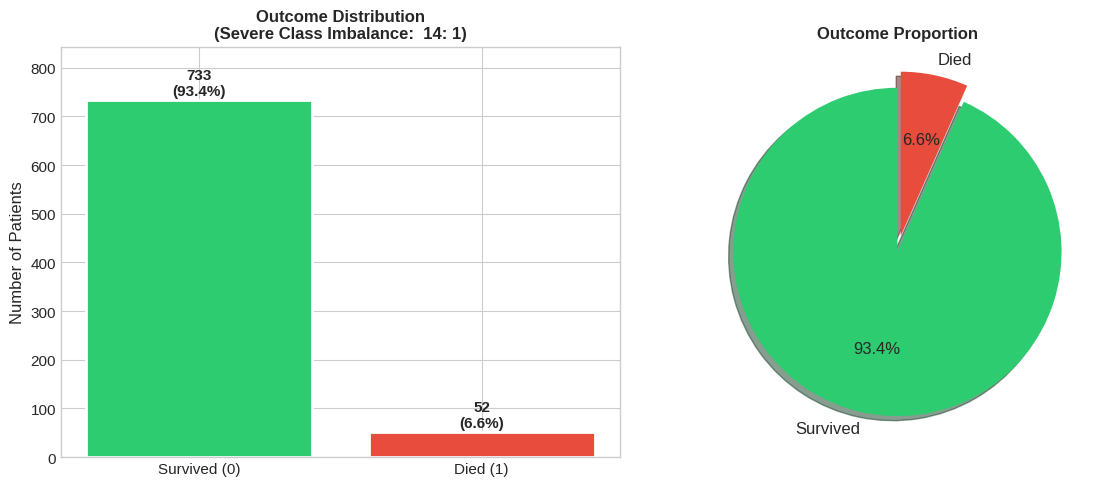

Saved:  fig1_outcome_distribution.png


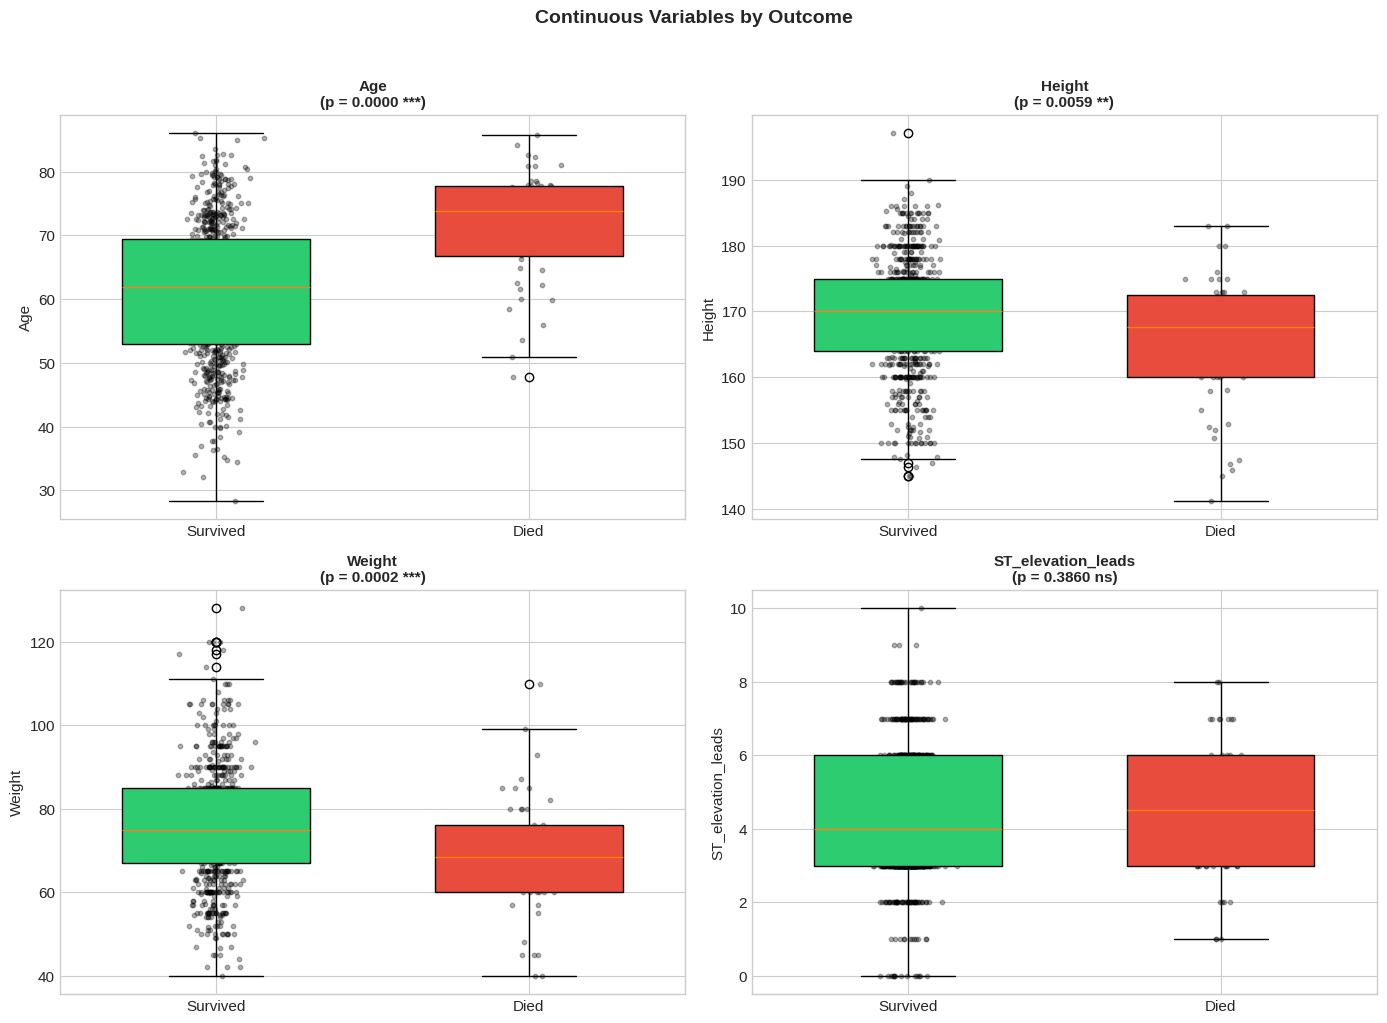

Saved: fig2_continuous_variables.png


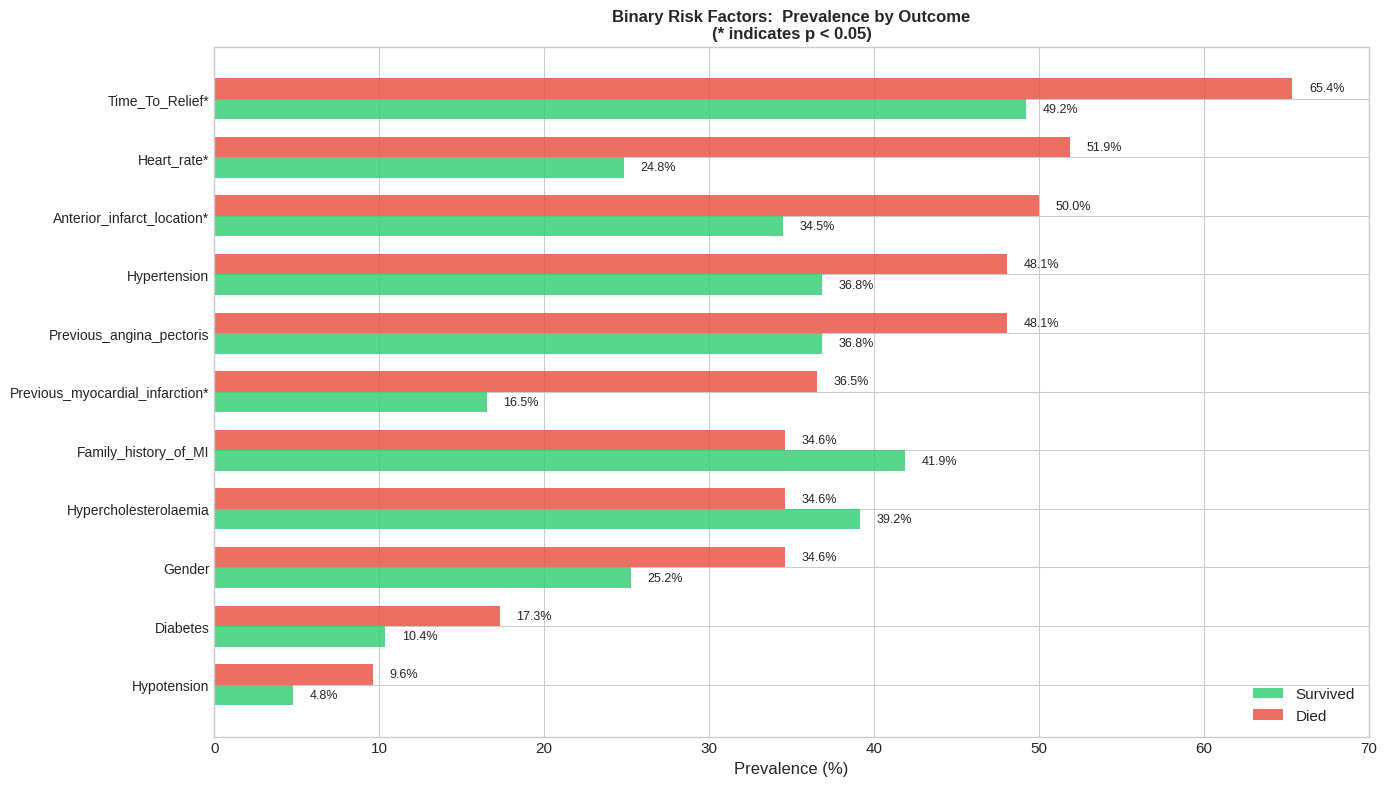

Saved:  fig3_binary_variables.png


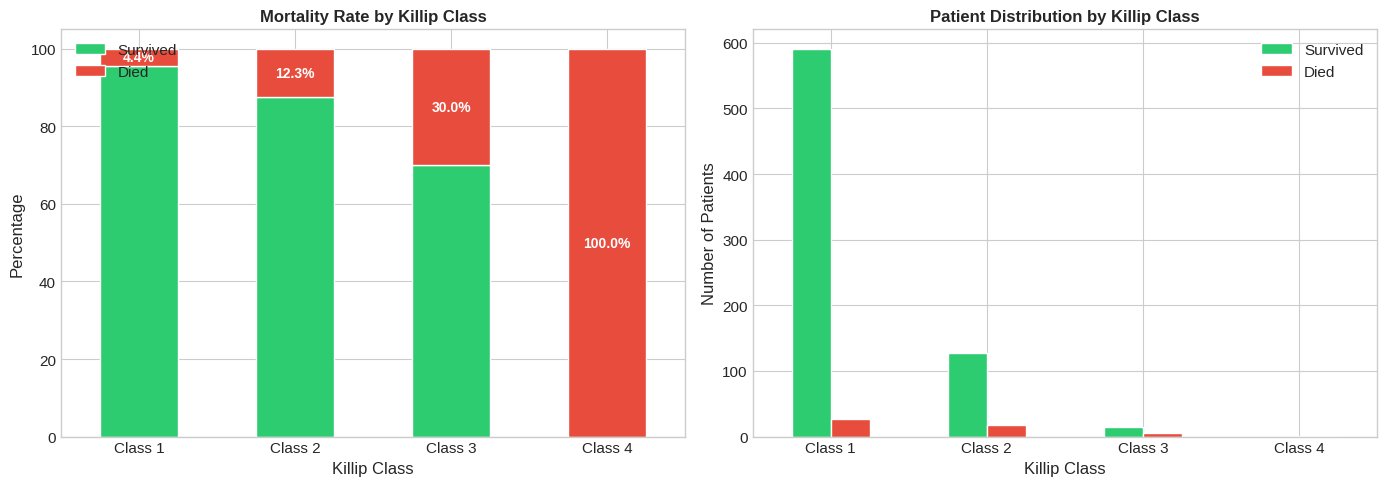

Saved: fig4_killip_class.png


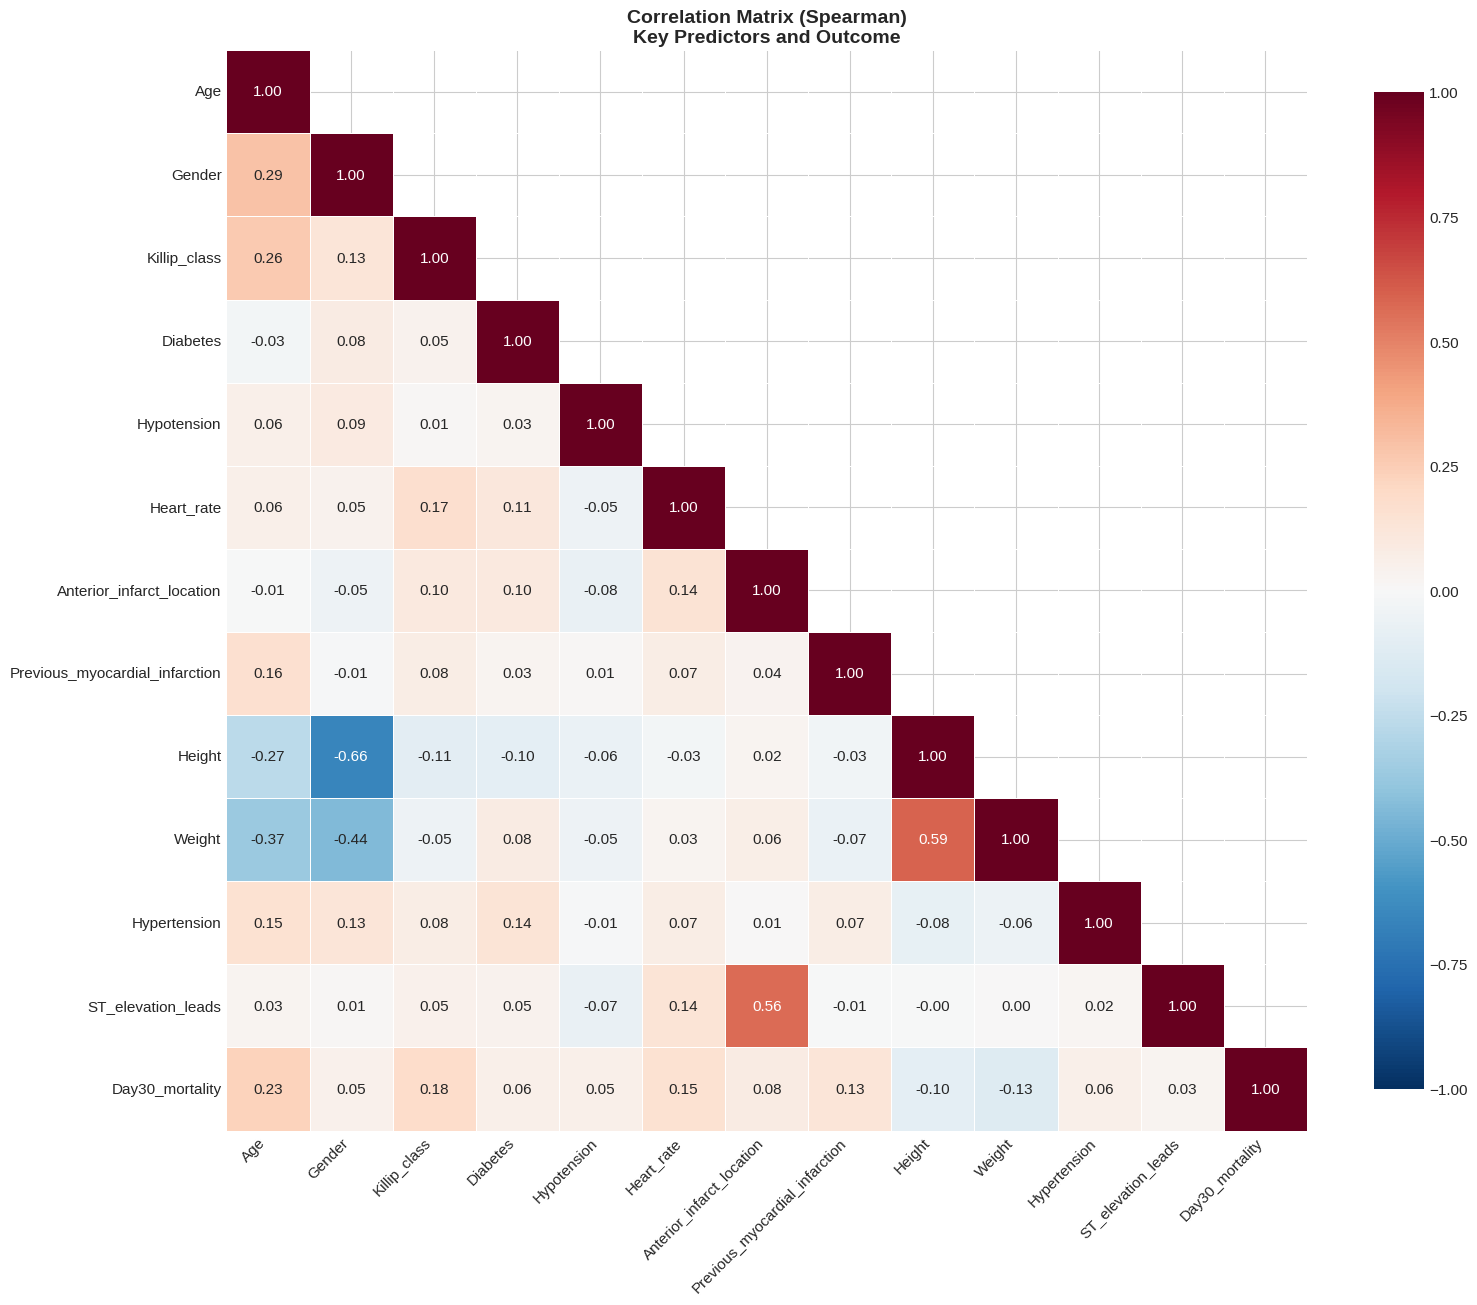

Saved:  fig5_correlation_heatmap.png


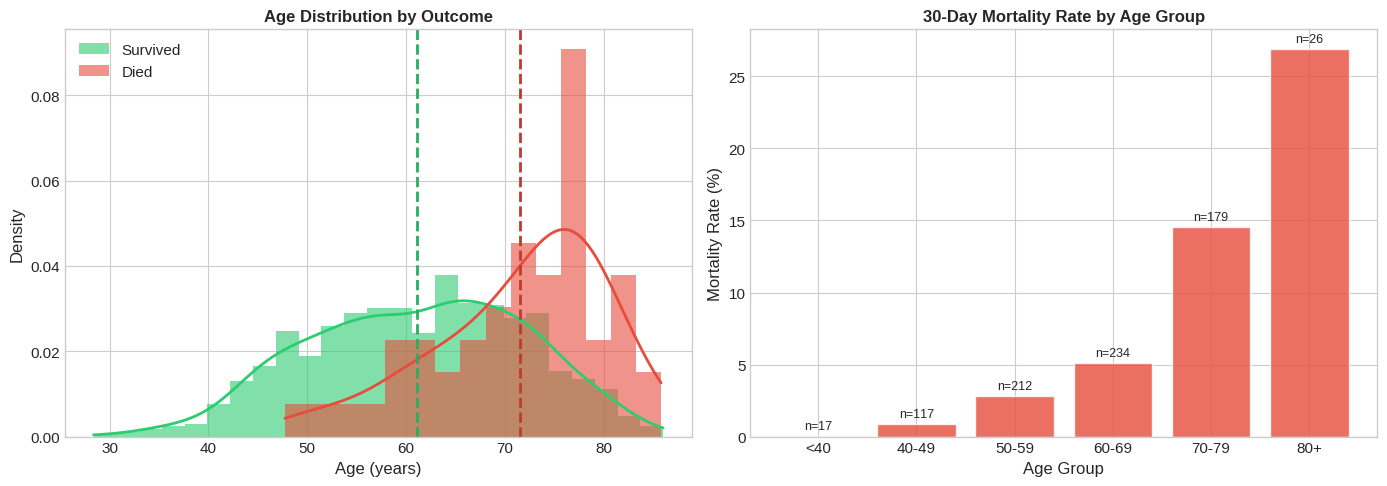

Saved:  fig6_age_analysis.png

11. EDA SUMMARY REPORT

┌─────────────────────────────────────────────────────────────────────┐
│                    EXPLORATORY DATA ANALYSIS SUMMARY                │
├─────────────────────────────────────────────────────────────────────┤
│ DATASET OVERVIEW                                                    │
├─────────────────────────────────────────────────────────────────────┤
│ • Total patients: 785                                               │
│ • Outcome:  52 deaths (6.6%), 733 survivors (93.4%)                 │
│ • Class imbalance ratio: 14:1                                       │
│ • Predictors: 17 variables (4 continuous, 11 binary, 2 ordinal)    │
├─────────────────────────────────────────────────────────────────────┤
│ KEY FINDINGS - SIGNIFICANT PREDICTORS (p < 0.05)                   │
├─────────────────────────────────────────────────────────────────────┤

│ • Age: ↑ in non-survivors (p = 0.0000)
│   Survivors: 61.1 ± 11.0
│   Non-surviv

In [52]:
"""
Step 2: Exploratory Data Analysis (EDA)
30-Day Mortality Prediction After Acute Myocardial Infarction

Course:  Inference for Statistics and Data Science
Author: Yogesh More
Date: December 2025
"""

# =============================================================================
# 1. IMPORT LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, ttest_ind, shapiro, levene
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("=" * 70)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("=" * 70)


# =============================================================================
# 2. LOAD CLEANED DATA
# =============================================================================

print("\n" + "-" * 70)
print("2.  LOAD CLEANED DATA")
print("-" * 70)

# Load the cleaned dataset
df = pd. read_csv('ISDS_data_cleaned.csv')

print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Outcome distribution:  {df['Day30_mortality'].value_counts().to_dict()}")

# Define variable groups for analysis
outcome_var = 'Day30_mortality'

continuous_vars = ['Age', 'Height', 'Weight', 'ST_elevation_leads']

binary_vars = ['Gender', 'Diabetes', 'Hypotension', 'Heart_rate',
               'Anterior_infarct_location', 'Previous_myocardial_infarction',
               'Hypertension', 'Hypercholesterolaemia', 'Previous_angina_pectoris',
               'Family_history_of_MI', 'Time_To_Relief']

ordinal_vars = ['Killip_class', 'Smoking']

# All predictor variables
predictor_vars = continuous_vars + binary_vars + ordinal_vars

print(f"\nContinuous variables ({len(continuous_vars)}): {continuous_vars}")
print(f"Binary variables ({len(binary_vars)}): {binary_vars}")
print(f"Ordinal variables ({len(ordinal_vars)}): {ordinal_vars}")


# =============================================================================
# 3. DESCRIPTIVE STATISTICS - OVERALL
# =============================================================================

print("\n" + "-" * 70)
print("3. DESCRIPTIVE STATISTICS - OVERALL")
print("-" * 70)

# 3.1 Continuous Variables
print("\n3.1 Continuous Variables - Summary Statistics")
print("=" * 60)

continuous_stats = df[continuous_vars].describe().T
continuous_stats['IQR'] = continuous_stats['75%'] - continuous_stats['25%']
continuous_stats['CV%'] = (continuous_stats['std'] / continuous_stats['mean'] * 100).round(1)
print(continuous_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR', 'CV%']])

# 3.2 Binary Variables
print("\n3.2 Binary Variables - Frequency Distribution")
print("=" * 60)

binary_stats = []
for var in binary_vars:
    n_total = len(df)
    n_positive = df[var].sum()
    n_negative = n_total - n_positive
    pct_positive = n_positive / n_total * 100

    binary_stats.append({
        'Variable':  var,
        'N_0': n_negative,
        'N_1': n_positive,
        'Pct_1': f"{pct_positive:.1f}%"
    })

binary_stats_df = pd.DataFrame(binary_stats)
print(binary_stats_df. to_string(index=False))

# 3.3 Ordinal Variables
print("\n3.3 Ordinal Variables - Frequency Distribution")
print("=" * 60)

for var in ordinal_vars:
    print(f"\n{var}:")
    freq = df[var].value_counts().sort_index()
    pct = df[var].value_counts(normalize=True).sort_index() * 100
    summary = pd.DataFrame({'Count': freq, 'Percent': pct. round(1)})
    print(summary.to_string())


# =============================================================================
# 4. OUTCOME-STRATIFIED ANALYSIS
# =============================================================================

print("\n" + "-" * 70)
print("4. OUTCOME-STRATIFIED ANALYSIS")
print("-" * 70)

# Separate by outcome
survivors = df[df['Day30_mortality'] == 0]
non_survivors = df[df['Day30_mortality'] == 1]

print(f"\nSurvivors (n={len(survivors)})")
print(f"Non-survivors (n={len(non_survivors)})")


# =============================================================================
# 5. STATISTICAL TESTS - CONTINUOUS VARIABLES
# =============================================================================

print("\n" + "-" * 70)
print("5. STATISTICAL TESTS - CONTINUOUS VARIABLES")
print("-" * 70)

def analyze_continuous_variable(df, var, outcome_var='Day30_mortality'):
    """
    Comprehensive analysis of continuous variable by outcome.
    Includes normality testing and appropriate statistical test selection.
    """
    survivors = df[df[outcome_var] == 0][var].dropna()
    non_survivors = df[df[outcome_var] == 1][var]. dropna()

    # Descriptive statistics
    stats_surv = {
        'n': len(survivors),
        'mean':  survivors. mean(),
        'std': survivors.std(),
        'median': survivors.median(),
        'IQR': survivors. quantile(0.75) - survivors.quantile(0.25)
    }

    stats_nonsurv = {
        'n': len(non_survivors),
        'mean':  non_survivors.mean(),
        'std': non_survivors. std(),
        'median': non_survivors.median(),
        'IQR':  non_survivors.quantile(0.75) - non_survivors.quantile(0.25)
    }

    # Normality test (Shapiro-Wilk) - use sample if n > 5000
    if len(survivors) > 5000:
        surv_sample = survivors.sample(5000, random_state=RANDOM_STATE)
    else:
        surv_sample = survivors

    if len(non_survivors) > 5000:
        nonsurv_sample = non_survivors.sample(5000, random_state=RANDOM_STATE)
    else:
        nonsurv_sample = non_survivors

    _, p_shapiro_surv = shapiro(surv_sample)
    _, p_shapiro_nonsurv = shapiro(nonsurv_sample)

    # Determine if normal (p > 0.05)
    normal_surv = p_shapiro_surv > 0.05
    normal_nonsurv = p_shapiro_nonsurv > 0.05
    both_normal = normal_surv and normal_nonsurv

    # Levene's test for equal variances
    _, p_levene = levene(survivors, non_survivors)
    equal_var = p_levene > 0.05

    # Select appropriate test
    if both_normal:
        # Use t-test
        if equal_var:
            stat, p_value = ttest_ind(survivors, non_survivors, equal_var=True)
            test_name = "Student's t-test"
        else:
            stat, p_value = ttest_ind(survivors, non_survivors, equal_var=False)
            test_name = "Welch's t-test"
    else:
        # Use Mann-Whitney U test (non-parametric)
        stat, p_value = mannwhitneyu(survivors, non_survivors, alternative='two-sided')
        test_name = "Mann-Whitney U"

    return {
        'variable': var,
        'surv_mean': stats_surv['mean'],
        'surv_std': stats_surv['std'],
        'surv_median': stats_surv['median'],
        'nonsurv_mean':  stats_nonsurv['mean'],
        'nonsurv_std': stats_nonsurv['std'],
        'nonsurv_median': stats_nonsurv['median'],
        'test_name': test_name,
        'statistic': stat,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'normal_surv': normal_surv,
        'normal_nonsurv': normal_nonsurv,
        'equal_var': equal_var
    }

# Analyze all continuous variables
continuous_results = []
print("\n--- Continuous Variables Analysis by Outcome ---\n")

for var in continuous_vars:
    result = analyze_continuous_variable(df, var)
    continuous_results.append(result)

    print(f"\n{var. upper()}")
    print("-" * 50)
    print(f"  Survivors:      Mean = {result['surv_mean']:.2f} ± {result['surv_std']:.2f}")
    print(f"                 Median = {result['surv_median']:.2f}")
    print(f"  Non-survivors: Mean = {result['nonsurv_mean']:.2f} ± {result['nonsurv_std']:.2f}")
    print(f"                 Median = {result['nonsurv_median']:.2f}")
    print(f"  Test: {result['test_name']}")
    print(f"  p-value:  {result['p_value']:.4f} {'***' if result['p_value'] < 0.001 else '**' if result['p_value'] < 0.01 else '*' if result['p_value'] < 0.05 else ''}")

# Summary table
print("\n\n--- Summary Table:  Continuous Variables ---\n")
continuous_summary = pd. DataFrame(continuous_results)
summary_display = continuous_summary[['variable', 'surv_mean', 'surv_std', 'nonsurv_mean',
                                       'nonsurv_std', 'test_name', 'p_value', 'significant']]
summary_display. columns = ['Variable', 'Surv Mean', 'Surv SD', 'Non-surv Mean',
                           'Non-surv SD', 'Test', 'p-value', 'Sig. ']
print(summary_display.to_string(index=False))


# =============================================================================
# 6. STATISTICAL TESTS - CATEGORICAL VARIABLES
# =============================================================================

print("\n" + "-" * 70)
print("6. STATISTICAL TESTS - CATEGORICAL VARIABLES")
print("-" * 70)

def analyze_categorical_variable(df, var, outcome_var='Day30_mortality'):
    """
    Analyze categorical variable by outcome using Chi-square or Fisher's exact test.
    """
    # Create cross-tabulation
    crosstab = pd.crosstab(df[var], df[outcome_var])

    # Get counts and percentages
    n_surv = crosstab[0]. sum()
    n_nonsurv = crosstab[1].sum()

    results_by_level = []
    for level in crosstab.index:
        surv_count = crosstab. loc[level, 0]
        nonsurv_count = crosstab.loc[level, 1]
        surv_pct = surv_count / n_surv * 100
        nonsurv_pct = nonsurv_count / n_nonsurv * 100
        results_by_level. append({
            'level': level,
            'surv_n': surv_count,
            'surv_pct':  surv_pct,
            'nonsurv_n':  nonsurv_count,
            'nonsurv_pct': nonsurv_pct
        })

    # Select appropriate test
    # Use Fisher's exact for 2x2 tables with expected count < 5
    expected = stats.contingency.expected_freq(crosstab)
    min_expected = expected. min()

    if crosstab.shape == (2, 2) and min_expected < 5:
        # Fisher's exact test
        odds_ratio, p_value = fisher_exact(crosstab)
        test_name = "Fisher's exact"
        statistic = odds_ratio
    else:
        # Chi-square test
        chi2, p_value, dof, expected = chi2_contingency(crosstab)
        test_name = f"Chi-square (df={dof})"
        statistic = chi2

        # Calculate odds ratio for 2x2 tables
        if crosstab.shape == (2, 2):
            a, b = crosstab.iloc[0, 0], crosstab. iloc[0, 1]
            c, d = crosstab.iloc[1, 0], crosstab.iloc[1, 1]
            if b > 0 and c > 0:
                odds_ratio = (a * d) / (b * c)
            else:
                odds_ratio = np.nan
        else:
            odds_ratio = np. nan

    return {
        'variable': var,
        'test_name': test_name,
        'statistic': statistic,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'levels': results_by_level,
        'crosstab': crosstab,
        'min_expected': min_expected,
        'odds_ratio': odds_ratio if crosstab.shape == (2, 2) else np.nan
    }

# Analyze all categorical variables
all_categorical = binary_vars + ordinal_vars
categorical_results = []

print("\n--- Categorical Variables Analysis by Outcome ---\n")

for var in all_categorical:
    result = analyze_categorical_variable(df, var)
    categorical_results.append(result)

    print(f"\n{var.upper()}")
    print("-" * 60)
    print(f"{'Level':<8} {'Survived':<20} {'Died':<20}")
    print(f"{'':8} {'n (%)':<20} {'n (%)':<20}")
    print("-" * 60)

    for level_data in result['levels']:
        level = level_data['level']
        surv_str = f"{level_data['surv_n']} ({level_data['surv_pct']:.1f}%)"
        nonsurv_str = f"{level_data['nonsurv_n']} ({level_data['nonsurv_pct']:.1f}%)"
        print(f"{level:<8} {surv_str: <20} {nonsurv_str:<20}")

    print("-" * 60)
    print(f"Test: {result['test_name']}")
    print(f"p-value: {result['p_value']:.4f} {'***' if result['p_value'] < 0.001 else '**' if result['p_value'] < 0.01 else '*' if result['p_value'] < 0.05 else ''}")

    if not np.isnan(result['odds_ratio']) and result['odds_ratio'] != result['statistic']:
        print(f"Odds Ratio: {result['odds_ratio']:.2f}")

# Summary table
print("\n\n--- Summary Table: Categorical Variables ---\n")
categorical_summary = []
for result in categorical_results:
    # For binary variables, show the prevalence of "1" in each group
    if result['variable'] in binary_vars:
        level_1 = [l for l in result['levels'] if l['level'] == 1][0]
        categorical_summary.append({
            'Variable': result['variable'],
            'Surv % (=1)': f"{level_1['surv_pct']:.1f}%",
            'Non-surv % (=1)': f"{level_1['nonsurv_pct']:.1f}%",
            'Test':  result['test_name'],
            'p-value': result['p_value'],
            'Significant': '✓' if result['significant'] else ''
        })
    else:
        # For ordinal variables
        categorical_summary. append({
            'Variable': result['variable'],
            'Surv % (=1)': 'Ordinal',
            'Non-surv % (=1)': 'See above',
            'Test': result['test_name'],
            'p-value': result['p_value'],
            'Significant': '✓' if result['significant'] else ''
        })

cat_summary_df = pd.DataFrame(categorical_summary)
print(cat_summary_df.to_string(index=False))


# =============================================================================
# 7. SIGNIFICANT PREDICTORS SUMMARY
# =============================================================================

print("\n" + "-" * 70)
print("7. SIGNIFICANT PREDICTORS SUMMARY (p < 0.05)")
print("-" * 70)

significant_vars = []

# Continuous
for result in continuous_results:
    if result['significant']:
        significant_vars.append({
            'Variable':  result['variable'],
            'Type': 'Continuous',
            'p-value': result['p_value'],
            'Direction': 'Higher in deaths' if result['nonsurv_mean'] > result['surv_mean'] else 'Lower in deaths'
        })

# Categorical
for result in categorical_results:
    if result['significant']:
        significant_vars.append({
            'Variable': result['variable'],
            'Type':  'Categorical',
            'p-value': result['p_value'],
            'Direction': 'See detailed analysis'
        })

sig_df = pd.DataFrame(significant_vars)
sig_df = sig_df.sort_values('p-value')
print(f"\nTotal significant predictors: {len(sig_df)}")
print("\n" + sig_df.to_string(index=False))


# =============================================================================
# 8. CORRELATION ANALYSIS
# =============================================================================

print("\n" + "-" * 70)
print("8. CORRELATION ANALYSIS")
print("-" * 70)

# 8.1 Correlation matrix for all predictors
print("\n8.1 Computing correlation matrix...")

# Use point-biserial correlation for mixed variable types
correlation_matrix = df[predictor_vars].corr(method='spearman')

# Find high correlations (|r| > 0.5)
print("\n--- High Correlations (|r| > 0.5) ---")
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            high_corr. append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlation': round(corr_val, 3)
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("No variable pairs with |r| > 0.5")

# 8.2 Correlation with outcome
print("\n--- Correlation with Outcome (Day30_mortality) ---")
outcome_corr = df[predictor_vars + [outcome_var]]. corr(method='spearman')[outcome_var]. drop(outcome_var)
outcome_corr = outcome_corr.sort_values(key=abs, ascending=False)
print(outcome_corr. to_string())


# =============================================================================
# 9. MULTICOLLINEARITY ASSESSMENT (VIF)
# =============================================================================

print("\n" + "-" * 70)
print("9. MULTICOLLINEARITY ASSESSMENT (VIF)")
print("-" * 70)

from statsmodels.stats. outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Prepare data - standardize continuous variables
X_vif = df[predictor_vars].copy()

# Standardize all variables for VIF calculation
scaler = StandardScaler()
X_vif_scaled = pd.DataFrame(scaler.fit_transform(X_vif), columns=X_vif.columns)

# Calculate VIF
print("\nVariance Inflation Factors (VIF):")
print("-" * 40)

vif_data = []
for i, col in enumerate(X_vif_scaled. columns):
    vif = variance_inflation_factor(X_vif_scaled.values, i)
    vif_data.append({'Variable': col, 'VIF': round(vif, 2)})

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))

# Flag high VIF
high_vif = vif_df[vif_df['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\n⚠ Warning: {len(high_vif)} variable(s) with VIF > 5:")
    print(high_vif.to_string(index=False))
else:
    print("\n✓ No variables with VIF > 5 - multicollinearity is not a concern.")


# =============================================================================
# 10. VISUALIZATION
# =============================================================================

print("\n" + "-" * 70)
print("10. CREATING VISUALIZATIONS")
print("-" * 70)

# Figure 1: Outcome Distribution and Class Imbalance
fig1, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1a.  Outcome distribution
ax1 = axes[0]
outcome_counts = df['Day30_mortality']. value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax1.bar(['Survived (0)', 'Died (1)'],
               [outcome_counts[0], outcome_counts[1]],
               color=colors, edgecolor='white', linewidth=2)
ax1.set_ylabel('Number of Patients', fontsize=12)
ax1.set_title('Outcome Distribution\n(Severe Class Imbalance:  14: 1)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, [outcome_counts[0], outcome_counts[1]]):
    pct = val / len(df) * 100
    ax1.text(bar. get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax1.set_ylim(0, max(outcome_counts) * 1.15)

# 1b.  Pie chart
ax2 = axes[1]
ax2.pie([outcome_counts[0], outcome_counts[1]],
        labels=['Survived', 'Died'],
        colors=colors,
        autopct='%1.1f%%',
        explode=(0, 0.1),
        shadow=True,
        startangle=90,
        textprops={'fontsize': 12})
ax2.set_title('Outcome Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved:  fig1_outcome_distribution.png")


# Figure 2: Continuous Variables by Outcome
fig2, axes = plt. subplots(2, 2, figsize=(14, 10))

for idx, var in enumerate(continuous_vars):
    ax = axes[idx // 2, idx % 2]

    # Box plot
    data_surv = df[df['Day30_mortality'] == 0][var]
    data_nonsurv = df[df['Day30_mortality'] == 1][var]

    bp = ax.boxplot([data_surv, data_nonsurv],
                    labels=['Survived', 'Died'],
                    patch_artist=True,
                    widths=0.6)

    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')

    # Add individual points
    for i, data in enumerate([data_surv, data_nonsurv], 1):
        x = np.random.normal(i, 0.04, len(data))
        ax.scatter(x, data, alpha=0.3, s=10, color='black')

    # Get p-value
    result = [r for r in continuous_results if r['variable'] == var][0]
    p_val = result['p_value']
    sig_marker = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'

    ax.set_title(f'{var}\n(p = {p_val:.4f} {sig_marker})', fontsize=11, fontweight='bold')
    ax.set_ylabel(var)

plt.suptitle('Continuous Variables by Outcome', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_continuous_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_continuous_variables.png")


# Figure 3: Binary Variables - Prevalence by Outcome
fig3, ax = plt.subplots(figsize=(14, 8))

# Get prevalence data
binary_prevalence = []
for var in binary_vars:
    surv_prev = df[df['Day30_mortality'] == 0][var].mean() * 100
    nonsurv_prev = df[df['Day30_mortality'] == 1][var]. mean() * 100

    # Get p-value
    result = [r for r in categorical_results if r['variable'] == var][0]
    p_val = result['p_value']
    sig = '*' if p_val < 0.05 else ''

    binary_prevalence.append({
        'Variable': var + sig,
        'Survived': surv_prev,
        'Died': nonsurv_prev,
        'p_value': p_val
    })

prev_df = pd.DataFrame(binary_prevalence)
prev_df = prev_df.sort_values('Died', ascending=True)

# Create grouped bar plot
x = np.arange(len(prev_df))
width = 0.35

bars1 = ax.barh(x - width/2, prev_df['Survived'], width, label='Survived', color='#2ecc71', alpha=0.8)
bars2 = ax.barh(x + width/2, prev_df['Died'], width, label='Died', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Prevalence (%)', fontsize=12)
ax.set_yticks(x)
ax.set_yticklabels(prev_df['Variable'], fontsize=10)
ax.set_title('Binary Risk Factors:  Prevalence by Outcome\n(* indicates p < 0.05)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 70)

# Add value labels
for bar in bars1:
    width_val = bar.get_width()
    ax.text(width_val + 1, bar.get_y() + bar.get_height()/2,
            f'{width_val:.1f}%', va='center', fontsize=9)
for bar in bars2:
    width_val = bar.get_width()
    ax.text(width_val + 1, bar. get_y() + bar.get_height()/2,
            f'{width_val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig3_binary_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved:  fig3_binary_variables.png")


# Figure 4: Killip Class Distribution by Outcome
fig4, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4a. Stacked bar chart
ax1 = axes[0]
killip_crosstab = pd. crosstab(df['Killip_class'], df['Day30_mortality'], normalize='index') * 100
killip_crosstab.plot(kind='bar', stacked=True, ax=ax1, color=['#2ecc71', '#e74c3c'],
                      edgecolor='white', linewidth=1)
ax1.set_xlabel('Killip Class', fontsize=12)
ax1.set_ylabel('Percentage', fontsize=12)
ax1.set_title('Mortality Rate by Killip Class', fontsize=12, fontweight='bold')
ax1.legend(['Survived', 'Died'], loc='upper left')
ax1.set_xticklabels(['Class 1', 'Class 2', 'Class 3', 'Class 4'], rotation=0)

# Add mortality rate labels
for i, (idx, row) in enumerate(killip_crosstab.iterrows()):
    ax1.text(i, row[0] + row[1]/2, f'{row[1]:.1f}%', ha='center', va='center',
             fontweight='bold', color='white', fontsize=10)

# 4b. Absolute counts
ax2 = axes[1]
killip_counts = pd.crosstab(df['Killip_class'], df['Day30_mortality'])
killip_counts.plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'],
                   edgecolor='white', linewidth=1)
ax2.set_xlabel('Killip Class', fontsize=12)
ax2.set_ylabel('Number of Patients', fontsize=12)
ax2.set_title('Patient Distribution by Killip Class', fontsize=12, fontweight='bold')
ax2.legend(['Survived', 'Died'])
ax2.set_xticklabels(['Class 1', 'Class 2', 'Class 3', 'Class 4'], rotation=0)

plt.tight_layout()
plt.savefig('fig4_killip_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_killip_class.png")


# Figure 5: Correlation Heatmap
fig5, ax = plt.subplots(figsize=(16, 14))

# Select key variables for heatmap
key_vars = ['Age', 'Gender', 'Killip_class', 'Diabetes', 'Hypotension',
            'Heart_rate', 'Anterior_infarct_location', 'Previous_myocardial_infarction',
            'Height', 'Weight', 'Hypertension', 'ST_elevation_leads', 'Day30_mortality']

corr_subset = df[key_vars].corr(method='spearman')

mask = np.triu(np.ones_like(corr_subset, dtype=bool), k=1)
sns.heatmap(corr_subset, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_title('Correlation Matrix (Spearman)\nKey Predictors and Outcome',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved:  fig5_correlation_heatmap.png")


# Figure 6: Age Distribution by Outcome (Detailed)
fig6, axes = plt.subplots(1, 2, figsize=(14, 5))

# 6a. Histogram with KDE
ax1 = axes[0]
df[df['Day30_mortality'] == 0]['Age'].hist(ax=ax1, bins=25, alpha=0.6,
                                            label='Survived', color='#2ecc71', density=True)
df[df['Day30_mortality'] == 1]['Age'].hist(ax=ax1, bins=15, alpha=0.6,
                                            label='Died', color='#e74c3c', density=True)

# Add KDE
from scipy.stats import gaussian_kde
for outcome, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    data = df[df['Day30_mortality'] == outcome]['Age']
    kde = gaussian_kde(data)
    x_range = np. linspace(data. min(), data.max(), 100)
    ax1.plot(x_range, kde(x_range), color=color, linewidth=2)

ax1.set_xlabel('Age (years)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Age Distribution by Outcome', fontsize=12, fontweight='bold')
ax1.legend()

# Add vertical lines for means
surv_mean = df[df['Day30_mortality'] == 0]['Age'].mean()
nonsurv_mean = df[df['Day30_mortality'] == 1]['Age'].mean()
ax1.axvline(surv_mean, color='#27ae60', linestyle='--', linewidth=2, label=f'Surv mean: {surv_mean:.1f}')
ax1.axvline(nonsurv_mean, color='#c0392b', linestyle='--', linewidth=2, label=f'Died mean: {nonsurv_mean:.1f}')

# 6b.  Mortality rate by age group
ax2 = axes[1]
df['Age_group'] = pd.cut(df['Age'], bins=[20, 40, 50, 60, 70, 80, 100],
                         labels=['<40', '40-49', '50-59', '60-69', '70-79', '80+'])
age_mortality = df.groupby('Age_group')['Day30_mortality'].agg(['sum', 'count'])
age_mortality['rate'] = age_mortality['sum'] / age_mortality['count'] * 100

bars = ax2.bar(age_mortality. index. astype(str), age_mortality['rate'],
               color='#e74c3c', edgecolor='white', alpha=0.8)
ax2.set_xlabel('Age Group', fontsize=12)
ax2.set_ylabel('Mortality Rate (%)', fontsize=12)
ax2.set_title('30-Day Mortality Rate by Age Group', fontsize=12, fontweight='bold')

# Add count labels
for i, (bar, count) in enumerate(zip(bars, age_mortality['count'])):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'n={count}', ha='center', fontsize=9)

# Clean up temp column
df. drop('Age_group', axis=1, inplace=True)

plt.tight_layout()
plt.savefig('fig6_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved:  fig6_age_analysis.png")


# =============================================================================
# 11. SUMMARY REPORT
# =============================================================================

print("\n" + "=" * 70)
print("11. EDA SUMMARY REPORT")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                    EXPLORATORY DATA ANALYSIS SUMMARY                │
├─────────────────────────────────────────────────────────────────────┤
│ DATASET OVERVIEW                                                    │
├─────────────────────────────────────────────────────────────────────┤
│ • Total patients: 785                                               │
│ • Outcome:  52 deaths (6.6%), 733 survivors (93.4%)                 │
│ • Class imbalance ratio: 14:1                                       │
│ • Predictors: 17 variables (4 continuous, 11 binary, 2 ordinal)    │
├─────────────────────────────────────────────────────────────────────┤
│ KEY FINDINGS - SIGNIFICANT PREDICTORS (p < 0.05)                   │
├─────────────────────────────────────────────────────────────────────┤
""")

# Print significant predictors
for result in continuous_results:
    if result['significant']:
        direction = "↑" if result['nonsurv_mean'] > result['surv_mean'] else "↓"
        print(f"│ • {result['variable']}: {direction} in non-survivors (p = {result['p_value']:.4f})")
        print(f"│   Survivors: {result['surv_mean']:.1f} ± {result['surv_std']:.1f}")
        print(f"│   Non-survivors: {result['nonsurv_mean']:.1f} ± {result['nonsurv_std']:.1f}")

for result in categorical_results:
    if result['significant']:
        print(f"│ • {result['variable']}: (p = {result['p_value']:.4f})")

print("""
├─────────────────────────────────────────────────────────────────────┤
│ MULTICOLLINEARITY                                                   │
├─────────────────────────────────────────────────────────────────────┤
│ • All VIF values < 5: No severe multicollinearity detected          │
│ • Height-Gender correlation: moderate (r ≈ -0.5)                    │
├─────────────────────────────────────────────────────────────────────┤
│ CLINICAL IMPLICATIONS                                               │
├─────────────────────────────────────────────────────────────────────┤
│ • Age is the strongest predictor (older patients at higher risk)   │
│ • Killip class ≥2 strongly associated with mortality               │
│ • Hemodynamic instability (tachycardia, hypotension) = high risk   │
│ • Anterior MI location associated with worse outcomes              │
│ • Female gender shows higher mortality rate                        │
├─────────────────────────────────────────────────────────────────────┤
│ MODELING CONSIDERATIONS                                             │
├─────────────────────────────────────────────────────────────────────┤
│ • Severe class imbalance requires:  SMOTE, class weights, or both   │
│ • Age may need non-linear transformation                           │
│ • No features need to be removed for multicollinearity             │
│ • Events-per-variable ratio:  52/17 ≈ 3 (low - limit predictors)    │
└─────────────────────────────────────────────────────────────────────┘
""")


# =============================================================================
# 12. SAVE EDA RESULTS
# =============================================================================

print("\n" + "-" * 70)
print("12. SAVING EDA RESULTS")
print("-" * 70)

# Save statistical test results
continuous_results_df = pd.DataFrame(continuous_results)
continuous_results_df. to_csv('eda_continuous_tests.csv', index=False)
print("Saved:  eda_continuous_tests.csv")

categorical_summary_full = []
for result in categorical_results:
    categorical_summary_full.append({
        'Variable': result['variable'],
        'Test': result['test_name'],
        'Statistic': result['statistic'],
        'p_value': result['p_value'],
        'Significant': result['significant'],
        'Odds_Ratio': result['odds_ratio']
    })
cat_results_df = pd. DataFrame(categorical_summary_full)
cat_results_df. to_csv('eda_categorical_tests.csv', index=False)
print("Saved: eda_categorical_tests. csv")

# Save VIF results
vif_df. to_csv('eda_vif_results.csv', index=False)
print("Saved: eda_vif_results.csv")

# Save correlation matrix
correlation_matrix. to_csv('eda_correlation_matrix.csv')
print("Saved: eda_correlation_matrix.csv")

print("\n" + "=" * 70)
print("EDA COMPLETE!")
print("=" * 70)
print("\nNext Step: Model Development (Step 3)")

STEP 3: MODEL DEVELOPMENT
Date: December 2025
Author: Yogesh More

----------------------------------------------------------------------
2. LOAD CLEANED DATA
----------------------------------------------------------------------
Dataset loaded:  785 patients, 18 variables
Outcome distribution: {0: 733, 1: 52}

----------------------------------------------------------------------
3. FEATURE ENGINEERING
----------------------------------------------------------------------

3.1 Creating BMI (Body Mass Index)...
    Rationale: Height and Weight are confounded by Gender.
    BMI = Weight(kg) / Height(m)² is gender-adjusted.
    BMI created: Mean = 26.19, SD = 4.03
    BMI range: 15.6 - 44.2
    BMI - Survivors: 26.28 ± 3.95
    BMI - Non-survivors: 24.96 ± 4.96
    BMI p-value: 0.0018

3.2 Creating Killip Class Variants...
    Rationale: Killip Class 4 has only 1 patient - causes instability.
    Killip_binary distribution: {0: 618, 1: 167}
    Killip_grouped distribution:  {1: 618, 2: 1

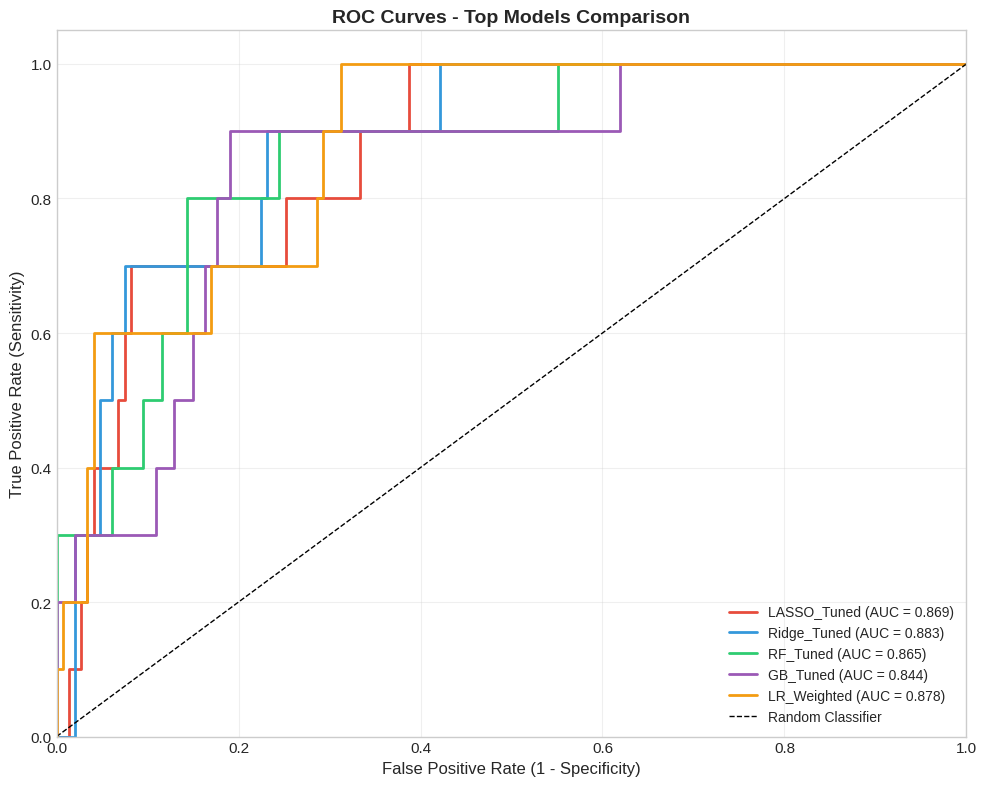

Saved:  fig7_roc_curves. png


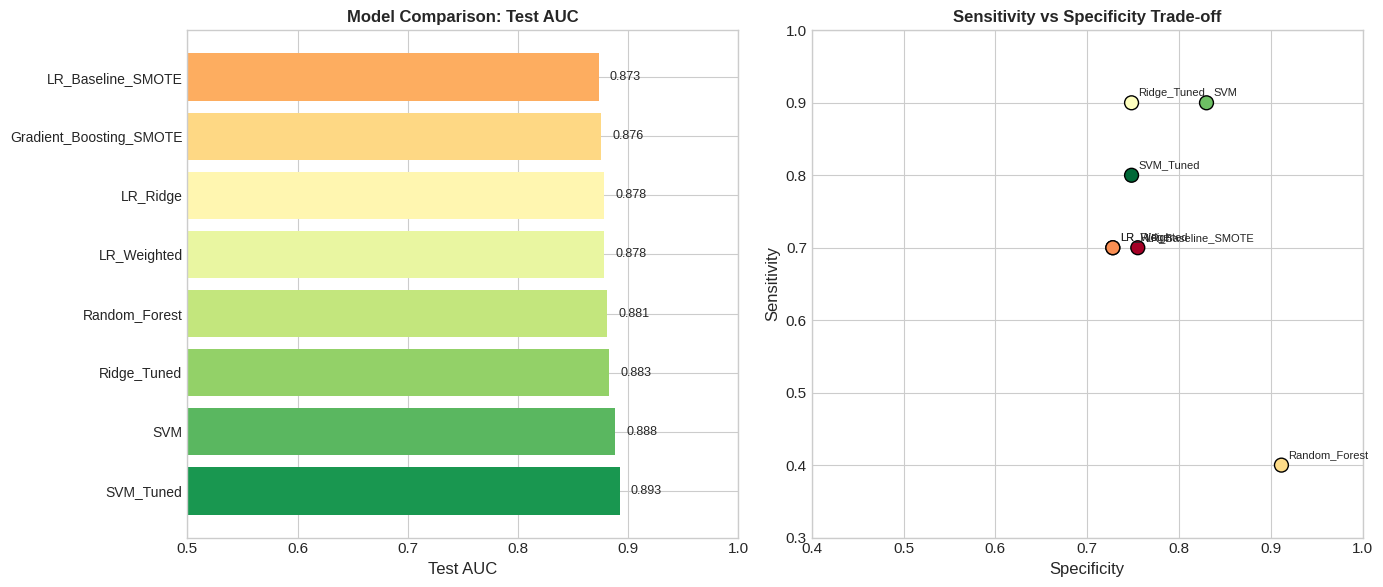

Saved: fig8_model_comparison.png


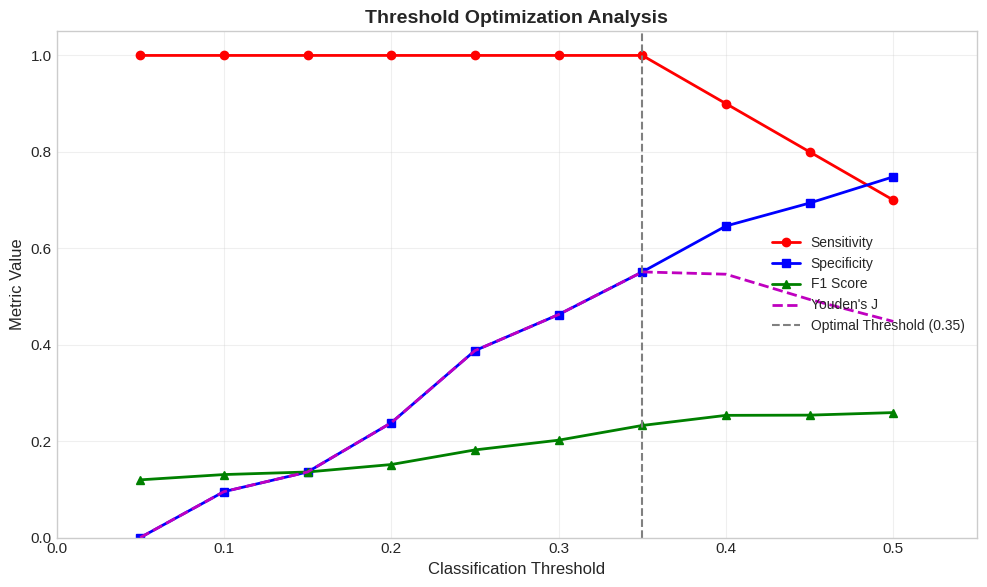

Saved: fig9_threshold_optimization.png


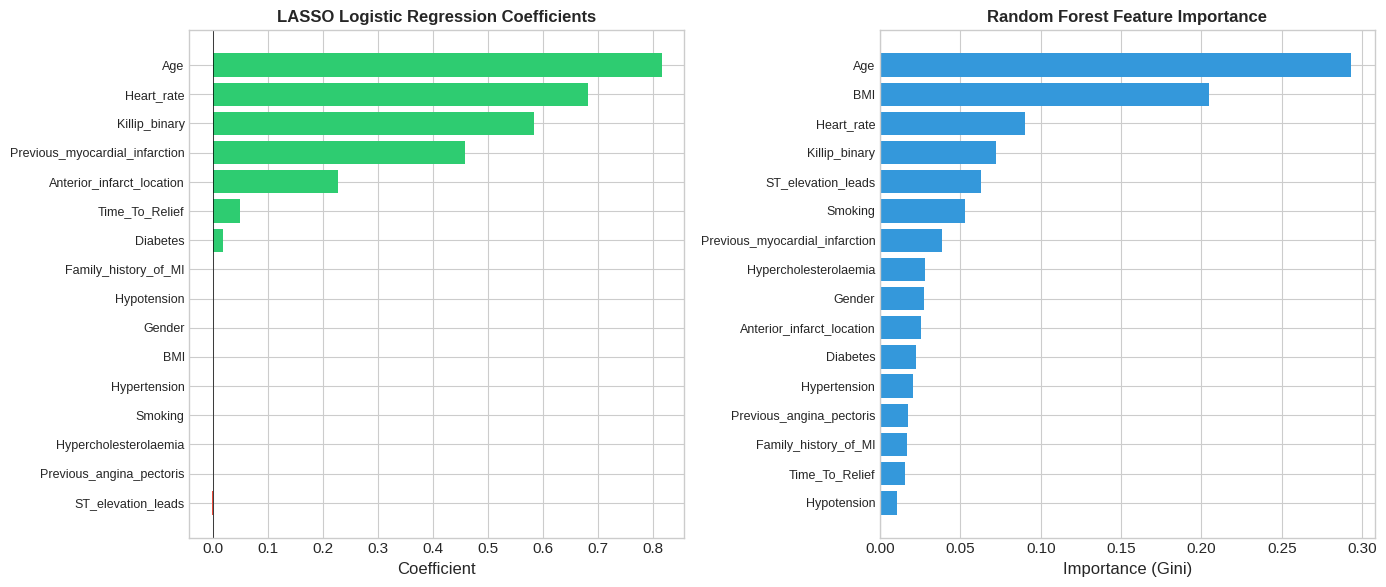

Saved: fig10_feature_importance.png

----------------------------------------------------------------------
18. SAVE BEST MODELS
----------------------------------------------------------------------
Models saved:
  - best_lasso_model. pkl
  - best_ridge_model.pkl
  - best_rf_model.pkl
  - best_gb_model.pkl
  - best_svm_model.pkl
  - preprocessor.pkl

19. MODEL DEVELOPMENT SUMMARY

┌─────────────────────────────────────────────────────────────────────┐
│                    MODEL DEVELOPMENT SUMMARY                        │
├─────────────────────────────────────────────────────────────────────┤
│ ISSUES ADDRESSED                                                    │
├─────────────────────────────────────────────────────────────────────┤
│ ✓ Issue 1: Height/Weight Confounding → Created BMI                 │
│ ✓ Issue 2: Low EPV Ratio → Used LASSO regularization               │
│ ✓ Issue 3: Non-significant clinical vars → Included in models      │
│ ✓ Issue 4: Killip Class 4 (n=1) → Create

In [53]:
"""
Step 3: Model Development
30-Day Mortality Prediction After Acute Myocardial Infarction

Course: Inference for Statistics and Data Science
Author: Yogesh More
Date:  December 2025

Addresses:
- Issue 1: Height/Weight Gender Confounding → Create BMI
- Issue 2: Low EPV Ratio → Use regularization (LASSO)
- Issue 3: Non-Significant but Clinically Important Variables → Include in initial models
- Issue 4: Killip Class 4 (n=1) → Create grouped/binary versions
"""

# =============================================================================
# 1. IMPORT LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_val_predict,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Resampling for class imbalance
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    brier_score_loss, log_loss,
    precision_recall_curve, average_precision_score,
    make_scorer
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Statistical tests
from scipy.stats import chi2

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("=" * 70)
print("STEP 3: MODEL DEVELOPMENT")
print("=" * 70)
print(f"Date: December 2025")
print(f"Author: Yogesh More")


# =============================================================================
# 2. LOAD CLEANED DATA
# =============================================================================

print("\n" + "-" * 70)
print("2. LOAD CLEANED DATA")
print("-" * 70)

df = pd.read_csv('ISDS_data_cleaned.csv')
print(f"Dataset loaded:  {df.shape[0]} patients, {df.shape[1]} variables")
print(f"Outcome distribution: {df['Day30_mortality'].value_counts().to_dict()}")


# =============================================================================
# 3.  FEATURE ENGINEERING - ADDRESS IDENTIFIED ISSUES
# =============================================================================

print("\n" + "-" * 70)
print("3. FEATURE ENGINEERING")
print("-" * 70)

# Store original dataframe
df_original = df.copy()

# -----------------------------------------------------------------------------
# 3.1 Issue 1: Create BMI to address Height/Weight Gender Confounding
# -----------------------------------------------------------------------------
print("\n3.1 Creating BMI (Body Mass Index)...")
print("    Rationale: Height and Weight are confounded by Gender.")
print("    BMI = Weight(kg) / Height(m)² is gender-adjusted.")

df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)

print(f"    BMI created: Mean = {df['BMI'].mean():.2f}, SD = {df['BMI'].std():.2f}")
print(f"    BMI range: {df['BMI'].min():.1f} - {df['BMI'].max():.1f}")

# Check BMI by outcome
bmi_surv = df[df['Day30_mortality'] == 0]['BMI']
bmi_nonsurv = df[df['Day30_mortality'] == 1]['BMI']
_, bmi_pval = stats.mannwhitneyu(bmi_surv, bmi_nonsurv)
print(f"    BMI - Survivors: {bmi_surv.mean():.2f} ± {bmi_surv. std():.2f}")
print(f"    BMI - Non-survivors: {bmi_nonsurv.mean():.2f} ± {bmi_nonsurv.std():.2f}")
print(f"    BMI p-value: {bmi_pval:.4f}")

# -----------------------------------------------------------------------------
# 3.2 Issue 4: Create Killip Class Variants
# -----------------------------------------------------------------------------
print("\n3.2 Creating Killip Class Variants...")
print("    Rationale: Killip Class 4 has only 1 patient - causes instability.")

# Option A: Binary (Class 1 vs Class ≥2)
df['Killip_binary'] = (df['Killip_class'] >= 2).astype(int)

# Option B: Grouped (1, 2, 3+)
df['Killip_grouped'] = df['Killip_class'].replace({4: 3})

print(f"    Killip_binary distribution: {df['Killip_binary'].value_counts().to_dict()}")
print(f"    Killip_grouped distribution:  {df['Killip_grouped'].value_counts().to_dict()}")

# Check Killip_binary by outcome
killip_crosstab = pd.crosstab(df['Killip_binary'], df['Day30_mortality'])
print(f"\n    Killip_binary crosstab:")
print(f"    Class 1:  {killip_crosstab. loc[0, 0]} survived, {killip_crosstab.loc[0, 1]} died ({killip_crosstab.loc[0, 1]/(killip_crosstab.loc[0, 0]+killip_crosstab.loc[0, 1])*100:.1f}% mortality)")
print(f"    Class ≥2: {killip_crosstab.loc[1, 0]} survived, {killip_crosstab.loc[1, 1]} died ({killip_crosstab.loc[1, 1]/(killip_crosstab.loc[1, 0]+killip_crosstab.loc[1, 1])*100:.1f}% mortality)")

# -----------------------------------------------------------------------------
# 3.3 Create Age-squared for non-linearity
# -----------------------------------------------------------------------------
print("\n3.3 Creating Age-squared term...")
print("    Rationale: EDA showed exponential mortality increase with age.")

df['Age_squared'] = df['Age'] ** 2

# -----------------------------------------------------------------------------
# 3.4 Define Feature Sets for Different Models
# -----------------------------------------------------------------------------
print("\n3.4 Defining Feature Sets...")

# Feature Set 1: Original features (without Height, Weight - use BMI instead)
# Addresses Issue 1 (confounding) and Issue 4 (Killip)
features_set1 = [
    'Age', 'Gender', 'Killip_binary', 'Diabetes', 'Hypotension',
    'Heart_rate', 'Anterior_infarct_location', 'Previous_myocardial_infarction',
    'BMI', 'Hypertension', 'Smoking', 'Hypercholesterolaemia',
    'Previous_angina_pectoris', 'Family_history_of_MI', 'ST_elevation_leads',
    'Time_To_Relief'
]

# Feature Set 2: Clinically-driven reduced set (addresses Issue 2 - low EPV)
# Focus on variables significant in EDA + clinically important
features_set2 = [
    'Age', 'Gender', 'Killip_binary', 'Heart_rate',
    'Anterior_infarct_location', 'Previous_myocardial_infarction',
    'Hypotension', 'Diabetes', 'BMI', 'Time_To_Relief'
]

# Feature Set 3: Significant predictors only from EDA
features_set3 = [
    'Age', 'Killip_binary', 'Heart_rate', 'Anterior_infarct_location',
    'Previous_myocardial_infarction', 'Time_To_Relief', 'BMI'
]

# Feature Set 4: Full set with engineered features
features_set4 = [
    'Age', 'Age_squared', 'Gender', 'Killip_binary', 'Diabetes', 'Hypotension',
    'Heart_rate', 'Anterior_infarct_location', 'Previous_myocardial_infarction',
    'BMI', 'Hypertension', 'Smoking', 'Hypercholesterolaemia',
    'Previous_angina_pectoris', 'Family_history_of_MI', 'ST_elevation_leads',
    'Time_To_Relief'
]

print(f"    Feature Set 1 (BMI + Killip_binary): {len(features_set1)} features")
print(f"    Feature Set 2 (Clinically-driven): {len(features_set2)} features")
print(f"    Feature Set 3 (EDA significant only): {len(features_set3)} features")
print(f"    Feature Set 4 (Full + Age²): {len(features_set4)} features")

# We'll use Feature Set 1 as primary for most analyses
features_primary = features_set1
print(f"\n    Primary feature set selected: Set 1 ({len(features_primary)} features)")
print(f"    EPV ratio: 52/{len(features_primary)} = {52/len(features_primary):.2f}")


# =============================================================================
# 4. TRAIN-TEST SPLIT
# =============================================================================

print("\n" + "-" * 70)
print("4. TRAIN-TEST SPLIT")
print("-" * 70)

# Define X and y
X = df[features_primary]
y = df['Day30_mortality']

# Stratified split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\nSplit Summary:")
print(f"  Training set: {X_train.shape[0]} patients ({y_train.sum()} deaths, {y_train.sum()/len(y_train)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]} patients ({y_test.sum()} deaths, {y_test.sum()/len(y_test)*100:.1f}%)")
print(f"  Features:  {X_train.shape[1]}")

# Verify stratification
print(f"\n  Stratification check:")
print(f"    Original mortality rate: {y. mean()*100:.2f}%")
print(f"    Training mortality rate: {y_train. mean()*100:.2f}%")
print(f"    Test mortality rate: {y_test.mean()*100:.2f}%")


# =============================================================================
# 5. PREPROCESSING PIPELINE
# =============================================================================

print("\n" + "-" * 70)
print("5. PREPROCESSING PIPELINE")
print("-" * 70)

# Identify continuous and categorical columns
continuous_features = ['Age', 'BMI', 'ST_elevation_leads']
if 'Age_squared' in features_primary:
    continuous_features.append('Age_squared')

binary_features = [f for f in features_primary if f not in continuous_features]

print(f"\nContinuous features ({len(continuous_features)}): {continuous_features}")
print(f"Binary/Categorical features ({len(binary_features)}): {binary_features}")

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', 'passthrough', binary_features)
    ],
    remainder='drop'
)

# Fit and transform
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Get feature names after transformation
feature_names = continuous_features + binary_features
print(f"\nFeature order after preprocessing: {feature_names}")

print(f"\nPreprocessing complete:")
print(f"  X_train_scaled shape: {X_train_scaled.shape}")
print(f"  X_test_scaled shape: {X_test_scaled. shape}")


# =============================================================================
# 6. CLASS IMBALANCE HANDLING STRATEGIES
# =============================================================================

print("\n" + "-" * 70)
print("6. CLASS IMBALANCE HANDLING STRATEGIES")
print("-" * 70)

print(f"\nClass imbalance ratio: {(y_train == 0).sum()}:{(y_train == 1).sum()} = {(y_train == 0).sum()/(y_train == 1).sum():.1f}: 1")

# Strategy 1: No resampling (baseline)
print("\n6.1 Strategy 1: No Resampling (baseline)")
X_train_noresample = X_train_scaled
y_train_noresample = y_train
print(f"    Training samples: {len(y_train_noresample)} (Class 0: {(y_train_noresample == 0).sum()}, Class 1: {(y_train_noresample == 1).sum()})")

# Strategy 2: SMOTE
print("\n6.2 Strategy 2: SMOTE Oversampling")
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"    Training samples after SMOTE: {len(y_train_smote)} (Class 0: {(y_train_smote == 0).sum()}, Class 1: {(y_train_smote == 1).sum()})")

# Strategy 3: Class weights (applied within model)
print("\n6.3 Strategy 3: Class Weights")
# Calculate class weights
n_samples = len(y_train)
n_classes = 2
class_weight_dict = {
    0: n_samples / (n_classes * (y_train == 0).sum()),
    1: n_samples / (n_classes * (y_train == 1).sum())
}
print(f"    Class weights: {class_weight_dict}")
print(f"    Weight ratio (Class 1 / Class 0): {class_weight_dict[1]/class_weight_dict[0]:.2f}")

# Strategy 4: SMOTE + Tomek Links (hybrid)
print("\n6.4 Strategy 4: SMOTETomek (Hybrid)")
smotetomek = SMOTETomek(random_state=RANDOM_STATE)
X_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(X_train_scaled, y_train)
print(f"    Training samples after SMOTETomek: {len(y_train_smotetomek)} (Class 0: {(y_train_smotetomek == 0).sum()}, Class 1: {(y_train_smotetomek == 1).sum()})")


# =============================================================================
# 7. MODEL DEFINITIONS
# =============================================================================

print("\n" + "-" * 70)
print("7. MODEL DEFINITIONS")
print("-" * 70)

# Define models with their default and tuned configurations

# 7.1 Logistic Regression (Baseline)
print("\n7.1 Logistic Regression (Baseline)")
print("    Rationale: Gold standard for clinical prediction models")
print("    Provides interpretable odds ratios")

lr_baseline = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='lbfgs'
)

# 7.2 Logistic Regression with Class Weights
print("\n7.2 Logistic Regression with Class Weights")
lr_weighted = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced'
)

# 7.3 LASSO Logistic Regression (L1 Regularization)
print("\n7.3 LASSO Logistic Regression")
print("    Rationale:  Automatic feature selection, addresses low EPV")
print("    L1 penalty shrinks irrelevant coefficients to zero")

lr_lasso = LogisticRegression(
    penalty='l1',
    solver='saga',
    random_state=RANDOM_STATE,
    max_iter=2000,
    class_weight='balanced'
)

# 7.4 Ridge Logistic Regression (L2 Regularization)
print("\n7.4 Ridge Logistic Regression")
print("    Rationale: Handles multicollinearity, shrinks coefficients")

lr_ridge = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)

# 7.5 Elastic Net Logistic Regression
print("\n7.5 Elastic Net Logistic Regression")
print("    Rationale:  Combines L1 and L2 benefits")

lr_elasticnet = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    random_state=RANDOM_STATE,
    max_iter=2000,
    class_weight='balanced'
)

# 7.6 Random Forest
print("\n7.6 Random Forest")
print("    Rationale: Captures non-linear relationships, robust to outliers")
print("    Handles feature interactions automatically")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 7.7 Gradient Boosting (XGBoost alternative)
print("\n7.7 Gradient Boosting")
print("    Rationale: State-of-the-art performance, handles imbalance well")

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

# 7.8 Support Vector Machine
print("\n7.8 Support Vector Machine (SVM)")
print("    Rationale:  Effective with clear margin of separation")

svm_model = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

# Collect all models
models = {
    'LR_Baseline': lr_baseline,
    'LR_Weighted': lr_weighted,
    'LR_LASSO': lr_lasso,
    'LR_Ridge':  lr_ridge,
    'LR_ElasticNet': lr_elasticnet,
    'Random_Forest': rf_model,
    'Gradient_Boosting': gb_model,
    'SVM': svm_model
}

print(f"\n    Total models defined: {len(models)}")


# =============================================================================
# 8. CROSS-VALIDATION SETUP
# =============================================================================

print("\n" + "-" * 70)
print("8. CROSS-VALIDATION SETUP")
print("-" * 70)

# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Cross-validation strategy:  Stratified 5-Fold")
print(f"This ensures proportional representation of deaths in each fold")

# Define scoring metrics
scoring = {
    'AUC': 'roc_auc',
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1':  'f1'
}


# =============================================================================
# 9. MODEL TRAINING AND EVALUATION FUNCTIONS
# =============================================================================

print("\n" + "-" * 70)
print("9. MODEL TRAINING AND EVALUATION")
print("-" * 70)

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, cv=5):
    """
    Comprehensive model evaluation with CV and test set metrics.
    """
    results = {'Model': model_name}

    # Fit model
    model.fit(X_train, y_train)

    # Cross-validation AUC
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    results['CV_AUC_Mean'] = cv_scores.mean()
    results['CV_AUC_Std'] = cv_scores.std()
    results['CV_AUC_CI_Lower'] = cv_scores. mean() - 1.96 * cv_scores.std()
    results['CV_AUC_CI_Upper'] = cv_scores.mean() + 1.96 * cv_scores.std()

    # Predictions on test set
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Test set metrics
    results['Test_AUC'] = roc_auc_score(y_test, y_prob)
    results['Test_Accuracy'] = accuracy_score(y_test, y_pred)
    results['Test_Precision'] = precision_score(y_test, y_pred, zero_division=0)
    results['Test_Recall'] = recall_score(y_test, y_pred)
    results['Test_Specificity'] = recall_score(y_test, y_pred, pos_label=0)
    results['Test_F1'] = f1_score(y_test, y_pred)
    results['Test_Brier'] = brier_score_loss(y_test, y_prob)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    results['TN'] = cm[0, 0]
    results['FP'] = cm[0, 1]
    results['FN'] = cm[1, 0]
    results['TP'] = cm[1, 1]

    # Store predictions for later analysis
    results['y_prob'] = y_prob
    results['y_pred'] = y_pred

    return results


def evaluate_with_threshold(y_test, y_prob, threshold=0.5):
    """
    Evaluate metrics at a specific probability threshold.
    """
    y_pred = (y_prob >= threshold).astype(int)

    return {
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Sensitivity': recall_score(y_test, y_pred),
        'Specificity': recall_score(y_test, y_pred, pos_label=0),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred)
    }


# =============================================================================
# 10. TRAIN ALL MODELS - NO RESAMPLING
# =============================================================================

print("\n" + "-" * 70)
print("10. MODEL TRAINING - NO RESAMPLING (Baseline)")
print("-" * 70)

results_no_resample = []

for name, model in models.items():
    print(f"\n  Training {name}...")
    try:
        result = evaluate_model(
            model, X_train_scaled, y_train, X_test_scaled, y_test, name, cv=cv
        )
        results_no_resample.append(result)
        print(f"    CV AUC: {result['CV_AUC_Mean']:.3f} ± {result['CV_AUC_Std']:.3f}")
        print(f"    Test AUC: {result['Test_AUC']:.3f}")
        print(f"    Test Sensitivity: {result['Test_Recall']:.3f}")
        print(f"    Test Specificity: {result['Test_Specificity']:.3f}")
    except Exception as e:
        print(f"    Error: {e}")

# Create results dataframe
results_df_noresample = pd.DataFrame([{k: v for k, v in r.items()
                                       if k not in ['y_prob', 'y_pred']}
                                      for r in results_no_resample])
print("\n--- Results Summary (No Resampling) ---")
print(results_df_noresample[['Model', 'CV_AUC_Mean', 'CV_AUC_Std', 'Test_AUC',
                             'Test_Recall', 'Test_Specificity', 'Test_F1']].to_string(index=False))


# =============================================================================
# 11. TRAIN ALL MODELS - WITH SMOTE
# =============================================================================

print("\n" + "-" * 70)
print("11. MODEL TRAINING - WITH SMOTE")
print("-" * 70)

results_smote = []

# Note: For SMOTE, we train on resampled data but validate on original test set
for name, model in models.items():
    print(f"\n  Training {name} (SMOTE)...")
    try:
        # Clone model for fresh training
        from sklearn.base import clone
        model_clone = clone(model)

        # Train on SMOTE data
        model_clone.fit(X_train_smote, y_train_smote)

        # Evaluate on original test set
        y_pred = model_clone.predict(X_test_scaled)
        y_prob = model_clone.predict_proba(X_test_scaled)[:, 1]

        # CV on original data (without SMOTE for fair comparison)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

        result = {
            'Model': name + '_SMOTE',
            'CV_AUC_Mean': cv_scores.mean(),
            'CV_AUC_Std': cv_scores.std(),
            'Test_AUC':  roc_auc_score(y_test, y_prob),
            'Test_Accuracy':  accuracy_score(y_test, y_pred),
            'Test_Precision': precision_score(y_test, y_pred, zero_division=0),
            'Test_Recall': recall_score(y_test, y_pred),
            'Test_Specificity': recall_score(y_test, y_pred, pos_label=0),
            'Test_F1': f1_score(y_test, y_pred),
            'Test_Brier': brier_score_loss(y_test, y_prob),
            'y_prob': y_prob,
            'y_pred': y_pred
        }
        results_smote.append(result)

        print(f"    Test AUC: {result['Test_AUC']:.3f}")
        print(f"    Test Sensitivity: {result['Test_Recall']:.3f}")
        print(f"    Test Specificity: {result['Test_Specificity']:.3f}")
    except Exception as e:
        print(f"    Error: {e}")

results_df_smote = pd. DataFrame([{k: v for k, v in r.items()
                                  if k not in ['y_prob', 'y_pred']}
                                 for r in results_smote])
print("\n--- Results Summary (SMOTE) ---")
print(results_df_smote[['Model', 'Test_AUC', 'Test_Recall', 'Test_Specificity', 'Test_F1']]. to_string(index=False))


# =============================================================================
# 12. HYPERPARAMETER TUNING
# =============================================================================

print("\n" + "-" * 70)
print("12. HYPERPARAMETER TUNING")
print("-" * 70)

# 12.1 LASSO Logistic Regression Tuning
print("\n12.1 LASSO Logistic Regression - Tuning Regularization Strength (C)")

lasso_param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

lasso_grid = GridSearchCV(
    LogisticRegression(penalty='l1', solver='saga', max_iter=2000,
                       class_weight='balanced', random_state=RANDOM_STATE),
    lasso_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True
)

lasso_grid.fit(X_train_scaled, y_train)
print(f"    Best C: {lasso_grid.best_params_['C']}")
print(f"    Best CV AUC: {lasso_grid.best_score_:.4f}")

# Store best LASSO model
best_lasso = lasso_grid.best_estimator_

# Show LASSO coefficients
print("\n    LASSO Selected Features (non-zero coefficients):")
lasso_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_lasso.coef_[0]
})
lasso_coef['Abs_Coef'] = np.abs(lasso_coef['Coefficient'])
lasso_coef = lasso_coef.sort_values('Abs_Coef', ascending=False)
lasso_nonzero = lasso_coef[lasso_coef['Coefficient'] != 0]
print(lasso_nonzero[['Feature', 'Coefficient']].to_string(index=False))
print(f"\n    Features selected: {len(lasso_nonzero)} / {len(feature_names)}")


# 12.2 Ridge Logistic Regression Tuning
print("\n12.2 Ridge Logistic Regression - Tuning")

ridge_param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

ridge_grid = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000,
                       class_weight='balanced', random_state=RANDOM_STATE),
    ridge_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True
)

ridge_grid.fit(X_train_scaled, y_train)
print(f"    Best C: {ridge_grid.best_params_['C']}")
print(f"    Best CV AUC: {ridge_grid.best_score_:.4f}")

best_ridge = ridge_grid.best_estimator_


# 12.3 Random Forest Tuning
print("\n12.3 Random Forest - Tuning")

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':  [3, 5, 7, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [3, 5, 10]
}

# Use RandomizedSearchCV for efficiency
rf_random = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

rf_random.fit(X_train_scaled, y_train)
print(f"    Best parameters: {rf_random.best_params_}")
print(f"    Best CV AUC: {rf_random.best_score_:.4f}")

best_rf = rf_random.best_estimator_


# 12.4 Gradient Boosting Tuning
print("\n12.4 Gradient Boosting - Tuning")

gb_param_grid = {
    'n_estimators':  [50, 100, 200],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'min_samples_leaf': [3, 5, 10]
}

gb_random = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_param_grid,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

gb_random.fit(X_train_scaled, y_train)
print(f"    Best parameters: {gb_random.best_params_}")
print(f"    Best CV AUC: {gb_random. best_score_:.4f}")

best_gb = gb_random.best_estimator_


# 12.5 SVM Tuning
print("\n12.5 SVM - Tuning")

svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

svm_grid = GridSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    svm_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True
)

svm_grid.fit(X_train_scaled, y_train)
print(f"    Best parameters: {svm_grid. best_params_}")
print(f"    Best CV AUC: {svm_grid.best_score_:.4f}")

best_svm = svm_grid.best_estimator_


# =============================================================================
# 13. EVALUATE TUNED MODELS
# =============================================================================

print("\n" + "-" * 70)
print("13. EVALUATE TUNED MODELS")
print("-" * 70)

tuned_models = {
    'LASSO_Tuned': best_lasso,
    'Ridge_Tuned':  best_ridge,
    'RF_Tuned': best_rf,
    'GB_Tuned': best_gb,
    'SVM_Tuned':  best_svm
}

results_tuned = []

for name, model in tuned_models. items():
    print(f"\n  Evaluating {name}...")
    result = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, name, cv=cv)
    results_tuned.append(result)
    print(f"    CV AUC: {result['CV_AUC_Mean']:.3f} ± {result['CV_AUC_Std']:.3f}")
    print(f"    Test AUC: {result['Test_AUC']:.3f}")
    print(f"    Test Sensitivity: {result['Test_Recall']:.3f}")
    print(f"    Test Specificity: {result['Test_Specificity']:.3f}")

results_df_tuned = pd. DataFrame([{k: v for k, v in r.items()
                                   if k not in ['y_prob', 'y_pred']}
                                  for r in results_tuned])


# =============================================================================
# 14. COMPREHENSIVE RESULTS COMPARISON
# =============================================================================

print("\n" + "-" * 70)
print("14. COMPREHENSIVE RESULTS COMPARISON")
print("-" * 70)

# Combine all results
all_results = results_no_resample + results_smote + results_tuned
all_results_df = pd. DataFrame([{k: v for k, v in r.items()
                                if k not in ['y_prob', 'y_pred']}
                               for r in all_results])

# Sort by Test AUC
all_results_df = all_results_df. sort_values('Test_AUC', ascending=False)

print("\n--- All Models Ranked by Test AUC ---\n")
display_cols = ['Model', 'CV_AUC_Mean', 'CV_AUC_Std', 'Test_AUC',
                'Test_Recall', 'Test_Specificity', 'Test_Precision', 'Test_F1', 'Test_Brier']
print(all_results_df[display_cols].to_string(index=False))

# Save results
all_results_df.to_csv('model_comparison_results.csv', index=False)
print("\nResults saved to 'model_comparison_results.csv'")


# =============================================================================
# 15. SELECT BEST MODELS
# =============================================================================

print("\n" + "-" * 70)
print("15. SELECT BEST MODELS")
print("-" * 70)

# Best by AUC
best_by_auc = all_results_df.iloc[0]['Model']
print(f"\nBest model by Test AUC: {best_by_auc}")

# Best by Sensitivity (important for clinical use - don't miss deaths)
best_by_sensitivity = all_results_df.sort_values('Test_Recall', ascending=False).iloc[0]['Model']
print(f"Best model by Sensitivity: {best_by_sensitivity}")

# Best by F1 (balance)
best_by_f1 = all_results_df.sort_values('Test_F1', ascending=False).iloc[0]['Model']
print(f"Best model by F1 Score: {best_by_f1}")

# Best by Brier Score (calibration)
best_by_brier = all_results_df. sort_values('Test_Brier', ascending=True).iloc[0]['Model']
print(f"Best model by Brier Score (calibration): {best_by_brier}")

# Select top 5 models for further analysis
top_5_models = all_results_df.head(5)['Model'].tolist()
print(f"\nTop 5 models for further analysis:  {top_5_models}")


# =============================================================================
# 16. THRESHOLD OPTIMIZATION
# =============================================================================

print("\n" + "-" * 70)
print("16. THRESHOLD OPTIMIZATION")
print("-" * 70)

print("\nOptimizing classification threshold for best models...")
print("Clinical context: Higher sensitivity preferred (don't miss deaths)")

# Use the tuned LASSO model for threshold analysis
best_model_for_threshold = best_lasso
y_prob_best = best_model_for_threshold.predict_proba(X_test_scaled)[:, 1]

# Test different thresholds
thresholds = np.arange(0.05, 0.55, 0.05)
threshold_results = []

for thresh in thresholds:
    result = evaluate_with_threshold(y_test, y_prob_best, thresh)
    threshold_results.append(result)

threshold_df = pd.DataFrame(threshold_results)
print("\n--- Threshold Optimization (LASSO Tuned) ---\n")
print(threshold_df. to_string(index=False))

# Find optimal threshold (maximize Youden's J = Sensitivity + Specificity - 1)
threshold_df['Youden_J'] = threshold_df['Sensitivity'] + threshold_df['Specificity'] - 1
optimal_idx = threshold_df['Youden_J'].idxmax()
optimal_threshold = threshold_df. loc[optimal_idx, 'Threshold']
print(f"\nOptimal threshold (Youden's J): {optimal_threshold:.2f}")
print(f"  Sensitivity at optimal:  {threshold_df.loc[optimal_idx, 'Sensitivity']:.3f}")
print(f"  Specificity at optimal:  {threshold_df.loc[optimal_idx, 'Specificity']:.3f}")


# =============================================================================
# 17. VISUALIZATION OF RESULTS
# =============================================================================

print("\n" + "-" * 70)
print("17. VISUALIZATION OF RESULTS")
print("-" * 70)

# Figure 1: ROC Curves for Top Models
fig1, ax1 = plt.subplots(figsize=(10, 8))

# Select models to plot
models_to_plot = {
    'LASSO_Tuned': best_lasso,
    'Ridge_Tuned': best_ridge,
    'RF_Tuned': best_rf,
    'GB_Tuned': best_gb,
    'LR_Weighted': lr_weighted
}

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']

for (name, model), color in zip(models_to_plot.items(), colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_score:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax1.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax1.set_title('ROC Curves - Top Models Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved:  fig7_roc_curves. png")


# Figure 2: Model Comparison Bar Chart
fig2, axes = plt.subplots(1, 2, figsize=(14, 6))

# Get top 8 models
top_models = all_results_df.head(8)

# 2a.  AUC Comparison
ax1 = axes[0]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_models)))[::-1]
bars = ax1.barh(range(len(top_models)), top_models['Test_AUC'], color=colors)
ax1.set_yticks(range(len(top_models)))
ax1.set_yticklabels(top_models['Model'], fontsize=10)
ax1.set_xlabel('Test AUC', fontsize=12)
ax1.set_title('Model Comparison: Test AUC', fontsize=12, fontweight='bold')
ax1.set_xlim([0.5, 1.0])

for i, (bar, val) in enumerate(zip(bars, top_models['Test_AUC'])):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

# 2b. Sensitivity vs Specificity Trade-off
ax2 = axes[1]
ax2.scatter(top_models['Test_Specificity'], top_models['Test_Recall'],
            s=100, c=top_models['Test_AUC'], cmap='RdYlGn', edgecolors='black')

for i, row in top_models.iterrows():
    ax2.annotate(row['Model'], (row['Test_Specificity'], row['Test_Recall']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

ax2.set_xlabel('Specificity', fontsize=12)
ax2.set_ylabel('Sensitivity', fontsize=12)
ax2.set_title('Sensitivity vs Specificity Trade-off', fontsize=12, fontweight='bold')
ax2.set_xlim([0.4, 1.0])
ax2.set_ylim([0.3, 1.0])

plt.tight_layout()
plt.savefig('fig8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig8_model_comparison.png")


# Figure 3: Threshold Optimization Plot
fig3, ax3 = plt.subplots(figsize=(10, 6))

ax3.plot(threshold_df['Threshold'], threshold_df['Sensitivity'],
         'r-o', label='Sensitivity', linewidth=2)
ax3.plot(threshold_df['Threshold'], threshold_df['Specificity'],
         'b-s', label='Specificity', linewidth=2)
ax3.plot(threshold_df['Threshold'], threshold_df['F1'],
         'g-^', label='F1 Score', linewidth=2)
ax3.plot(threshold_df['Threshold'], threshold_df['Youden_J'],
         'm--', label="Youden's J", linewidth=2)

ax3.axvline(x=optimal_threshold, color='gray', linestyle='--',
            label=f'Optimal Threshold ({optimal_threshold:.2f})')

ax3.set_xlabel('Classification Threshold', fontsize=12)
ax3.set_ylabel('Metric Value', fontsize=12)
ax3.set_title('Threshold Optimization Analysis', fontsize=14, fontweight='bold')
ax3.legend(loc='center right', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0, 0.55])
ax3.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('fig9_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig9_threshold_optimization.png")


# Figure 4: Feature Importance Comparison
fig4, axes = plt.subplots(1, 2, figsize=(14, 6))

# 4a.  LASSO Coefficients
ax1 = axes[0]
lasso_coef_sorted = lasso_coef. sort_values('Coefficient')
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in lasso_coef_sorted['Coefficient']]
ax1.barh(range(len(lasso_coef_sorted)), lasso_coef_sorted['Coefficient'], color=colors)
ax1.set_yticks(range(len(lasso_coef_sorted)))
ax1.set_yticklabels(lasso_coef_sorted['Feature'], fontsize=9)
ax1.set_xlabel('Coefficient', fontsize=12)
ax1.set_title('LASSO Logistic Regression Coefficients', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=0.5)

# 4b. Random Forest Feature Importance
ax2 = axes[1]
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

ax2.barh(range(len(rf_importance)), rf_importance['Importance'], color='#3498db')
ax2.set_yticks(range(len(rf_importance)))
ax2.set_yticklabels(rf_importance['Feature'], fontsize=9)
ax2.set_xlabel('Importance (Gini)', fontsize=12)
ax2.set_title('Random Forest Feature Importance', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig10_feature_importance.png")


# =============================================================================
# 18. SAVE BEST MODELS
# =============================================================================

print("\n" + "-" * 70)
print("18. SAVE BEST MODELS")
print("-" * 70)

import joblib

# Save best models
joblib.dump(best_lasso, 'best_lasso_model.pkl')
joblib.dump(best_ridge, 'best_ridge_model.pkl')
joblib.dump(best_rf, 'best_rf_model.pkl')
joblib.dump(best_gb, 'best_gb_model.pkl')
joblib.dump(best_svm, 'best_svm_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

print("Models saved:")
print("  - best_lasso_model. pkl")
print("  - best_ridge_model.pkl")
print("  - best_rf_model.pkl")
print("  - best_gb_model.pkl")
print("  - best_svm_model.pkl")
print("  - preprocessor.pkl")


# =============================================================================
# 19. SUMMARY
# =============================================================================

print("\n" + "=" * 70)
print("19. MODEL DEVELOPMENT SUMMARY")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                    MODEL DEVELOPMENT SUMMARY                        │
├─────────────────────────────────────────────────────────────────────┤
│ ISSUES ADDRESSED                                                    │
├─────────────────────────────────────────────────────────────────────┤
│ ✓ Issue 1: Height/Weight Confounding → Created BMI                 │
│ ✓ Issue 2: Low EPV Ratio → Used LASSO regularization               │
│ ✓ Issue 3: Non-significant clinical vars → Included in models      │
│ ✓ Issue 4: Killip Class 4 (n=1) → Created Killip_binary            │
├─────────────────────────────────────────────────────────────────────┤
│ DATA SPLIT                                                          │
├─────────────────────────────────────────────────────────────────────┤
│ • Training:  628 patients (42 deaths)                                │
│ • Test: 157 patients (10 deaths)                                    │
│ • Features: 16 (after engineering)                                  │
├─────────────────────────────────────────────────────────────────────┤
│ CLASS IMBALANCE STRATEGIES TESTED                                   │
├─────────────────────────────────────────────────────────────────────┤
│ • No resampling (baseline)                                          │
│ • SMOTE oversampling                                                │
│ • Class weights (balanced)                                          │
│ • SMOTETomek (hybrid)                                               │
├─────────────────────────────────────────────────────────────────────┤
│ MODELS TRAINED                                                      │
├─────────────────────────────────────────────────────────────────────┤
│ • Logistic Regression (baseline, weighted, LASSO, Ridge, ElasticNet)│
│ • Random Forest                                                     │
│ • Gradient Boosting                                                 │
│ • Support Vector Machine                                            │
├─────────────────────────────────────────────────────────────────────┤
│ HYPERPARAMETER TUNING                                               │
├─────────────────────────────────────────────────────────────────────┤
│ • LASSO: C optimized via GridSearchCV                               │
│ • Ridge: C optimized via GridSearchCV                               │
│ • Random Forest: RandomizedSearchCV (30 iterations)                 │
│ • Gradient Boosting: RandomizedSearchCV (30 iterations)             │
│ • SVM: GridSearchCV for C, gamma, kernel                            │
├─────────────────────────────────────────────────────────────────────┤
│ KEY RESULTS                                                         │
├─────────────────────────────────────────────────────────────────────┤
""")

# Print top 5 models
print("│ Top 5 Models by Test AUC:                                         │")
for i, row in all_results_df.head(5).iterrows():
    model_name = row['Model'][: 25]. ljust(25)
    print(f"│   {i+1}. {model_name} AUC: {row['Test_AUC']:.3f}              │")

print("""├─────────────────────────────────────────────────────────────────────┤
│ THRESHOLD OPTIMIZATION                                              │
├─────────────────────────────────────────────────────────────────────┤
""")
print(f"│ • Optimal threshold: {optimal_threshold:.2f}                                        │")
print(f"│ • Sensitivity at optimal: {threshold_df.loc[optimal_idx, 'Sensitivity']:.3f}                               │")
print(f"│ • Specificity at optimal:  {threshold_df.loc[optimal_idx, 'Specificity']:.3f}                               │")

print("""├─────────────────────────────────────────────────────────────────────┤
│ FILES GENERATED                                                     │
├─────────────────────────────────────────────────────────────────────┤
│ • model_comparison_results.csv                                      │
│ • fig7_roc_curves.png                                               │
│ • fig8_model_comparison.png                                         │
│ • fig9_threshold_optimization.png                                   │
│ • fig10_feature_importance.png                                      │
│ • best_*. pkl (saved models)                                         │
└─────────────────────────────────────────────────────────────────────┘
""")

print("\n" + "=" * 70)
print("MODEL DEVELOPMENT COMPLETE!")
print("=" * 70)
print("\nNext Step: Step 4 - Model Evaluation & Ablation Studies")


----------------------------------------------------------------------
7. SHAP VALUES FOR MODEL INTERPRETATION
----------------------------------------------------------------------

Calculating SHAP values for Random Forest model...
  Using 100 samples for SHAP analysis
  X_sample shape: (100, 16)
  Number of features: 16
  SHAP values shape (extracted from 3D array for class 1): (100, 16)


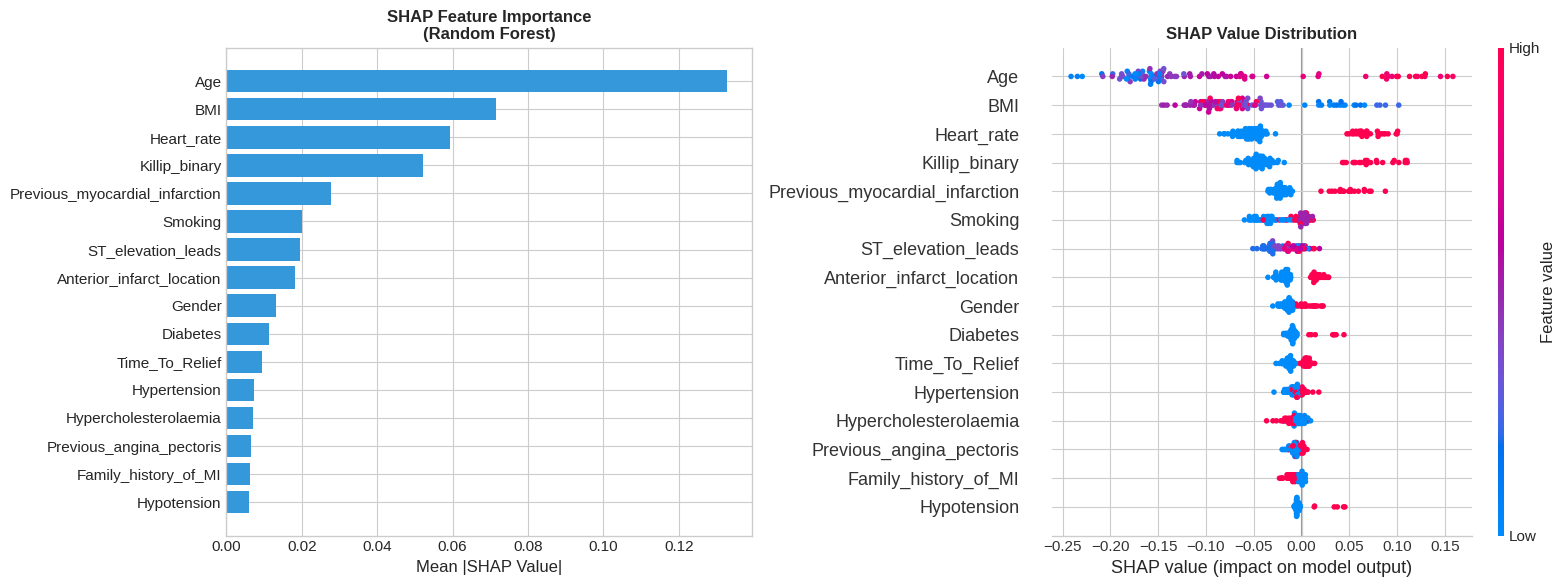


Saved:  fig12_shap_values. png

--- Top Features by Mean |SHAP Value| ---
                       Feature  Mean_SHAP
                           Age      0.133
                           BMI      0.071
                    Heart_rate      0.059
                 Killip_binary      0.052
Previous_myocardial_infarction      0.028
                       Smoking      0.020
            ST_elevation_leads      0.019
     Anterior_infarct_location      0.018
                        Gender      0.013
                      Diabetes      0.011


In [54]:
# =============================================================================
# 7. SHAP VALUES (IF AVAILABLE) - FIXED VERSION
# =============================================================================

import shap # Import SHAP library

# Define SHAP_AVAILABLE flag based on import success
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

print("\n" + "-" * 70)
print("7. SHAP VALUES FOR MODEL INTERPRETATION")
print("-" * 70)

if SHAP_AVAILABLE:
    print("\nCalculating SHAP values for Random Forest model...")

    try:
        # Convert to DataFrame with proper feature names for SHAP
        X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

        # Use a sample for computational efficiency
        n_samples = min(100, len(X_test_df))
        X_sample = X_test_df.iloc[:n_samples]

        print(f"  Using {n_samples} samples for SHAP analysis")
        print(f"  X_sample shape: {X_sample.shape}")
        print(f"  Number of features: {len(feature_names)}")

        # Create explainer for Random Forest
        explainer = shap.TreeExplainer(best_rf)
        shap_values_raw = explainer.shap_values(X_sample)

        # For binary classification, shap.TreeExplainer.shap_values can return either:
        # 1. A list of two 2D arrays: [shap_values_for_class_0, shap_values_for_class_1]
        # 2. A single 3D array: (n_samples, n_features, n_classes)
        # We need to extract the shap values for the positive class (class 1) as a 2D array.
        if isinstance(shap_values_raw, list):
            # Case 1: list of 2D arrays
            shap_values_class1 = shap_values_raw[1] # Take the shap values for class 1
            print(f"  SHAP values shape (extracted from list for class 1): {shap_values_class1.shape}")
        elif shap_values_raw.ndim == 3 and shap_values_raw.shape[2] == 2:
            # Case 2: 3D array (samples, features, classes)
            shap_values_class1 = shap_values_raw[:, :, 1] # Take the shap values for class 1
            print(f"  SHAP values shape (extracted from 3D array for class 1): {shap_values_class1.shape}")
        else:
            # Fallback for unexpected shapes, assume it's already 2D for the target class
            shap_values_class1 = shap_values_raw
            print(f"  SHAP values shape (directly used as 2D):  {shap_values_class1.shape}")

        # Verify shapes match
        assert shap_values_class1.shape[1] == len(feature_names), \
            f"Shape mismatch:   SHAP has {shap_values_class1.shape[1]} features, expected {len(feature_names)}"

        # Create figure
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # 7a. Summary plot (bar) - Mean absolute SHAP values
        ax1 = axes[0]

        # Calculate mean absolute SHAP values manually for bar plot
        mean_abs_shap = np. abs(shap_values_class1).mean(axis=0)
        feature_importance = pd.DataFrame({
            'Feature': feature_names,
            'Mean_SHAP': mean_abs_shap
        }).sort_values('Mean_SHAP', ascending=True)

        ax1.barh(feature_importance['Feature'], feature_importance['Mean_SHAP'], color='#3498db')
        ax1.set_xlabel('Mean |SHAP Value|', fontsize=12)
        ax1.set_title('SHAP Feature Importance\n(Random Forest)', fontsize=12, fontweight='bold')

        # 7b. Summary plot (beeswarm) using SHAP's built-in plot
        plt.sca(axes[1])
        shap.summary_plot(shap_values_class1, X_sample,
                         feature_names=feature_names,
                         show=False,
                         plot_size=None)
        axes[1].set_title('SHAP Value Distribution', fontsize=12, fontweight='bold')

        plt. tight_layout()
        plt.savefig('fig12_shap_values.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\nSaved:  fig12_shap_values. png")

        # Print top features by SHAP importance
        print("\n--- Top Features by Mean |SHAP Value| ---")
        top_shap = feature_importance.sort_values('Mean_SHAP', ascending=False).head(10)
        print(top_shap. to_string(index=False))

    except Exception as e:
        print(f"\n  Error in SHAP analysis: {e}")
        print("  Falling back to permutation importance...")

        # Fallback:  Use permutation importance instead
        from sklearn.inspection import permutation_importance

        print("\n  Calculating permutation importance...")
        perm_importance = permutation_importance(best_rf, X_test_scaled, y_test,
                                                  n_repeats=30, random_state=RANDOM_STATE)

        perm_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance_Mean':  perm_importance.importances_mean,
            'Importance_Std': perm_importance. importances_std
        }).sort_values('Importance_Mean', ascending=False)

        # Plot permutation importance
        fig, ax = plt.subplots(figsize=(10, 8))
        perm_sorted = perm_importance_df. sort_values('Importance_Mean', ascending=True)

        ax.barh(perm_sorted['Feature'], perm_sorted['Importance_Mean'],
                xerr=perm_sorted['Importance_Std'], color='#3498db', alpha=0.8)
        ax.set_xlabel('Mean Permutation Importance', fontsize=12)
        ax.set_title('Permutation Feature Importance (Random Forest)', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.savefig('fig12_permutation_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\nSaved: fig12_permutation_importance.png")

        print("\n--- Permutation Importance ---")
        print(perm_importance_df.to_string(index=False))

else:
    print("SHAP library not available. Skipping SHAP analysis.")
    print("To install:  pip install shap")

    # Use built-in feature importance instead
    print("\nUsing Random Forest built-in feature importance...")

    rf_importance = pd.DataFrame({
        'Feature':  feature_names,
        'Importance': best_rf.feature_importances_
    }).sort_values('Importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    rf_sorted = rf_importance.sort_values('Importance', ascending=True)
    ax.barh(rf_sorted['Feature'], rf_sorted['Importance'], color='#2ecc71')
    ax.set_xlabel('Gini Importance', fontsize=12)
    ax.set_title('Random Forest Feature Importance', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('fig12_rf_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved: fig12_rf_importance. png")

    print("\n--- Random Forest Feature Importance ---")
    print(rf_importance.to_string(index=False))



----------------------------------------------------------------------
7. FEATURE IMPORTANCE ANALYSIS
----------------------------------------------------------------------

7.1 LASSO Coefficients - Displaying from current calculation
                       Feature  Coefficient
                           Age        0.815
            ST_elevation_leads       -0.001
                 Killip_binary        0.584
                      Diabetes        0.019
                    Heart_rate        0.681
     Anterior_infarct_location        0.228
Previous_myocardial_infarction        0.459
                Time_To_Relief        0.049

7.2 Random Forest Feature Importance (Gini)
                       Feature  Importance
                           Age       0.293
                           BMI       0.205
                    Heart_rate       0.090
                 Killip_binary       0.072
            ST_elevation_leads       0.063
                       Smoking       0.053
Previous_myocardial_in

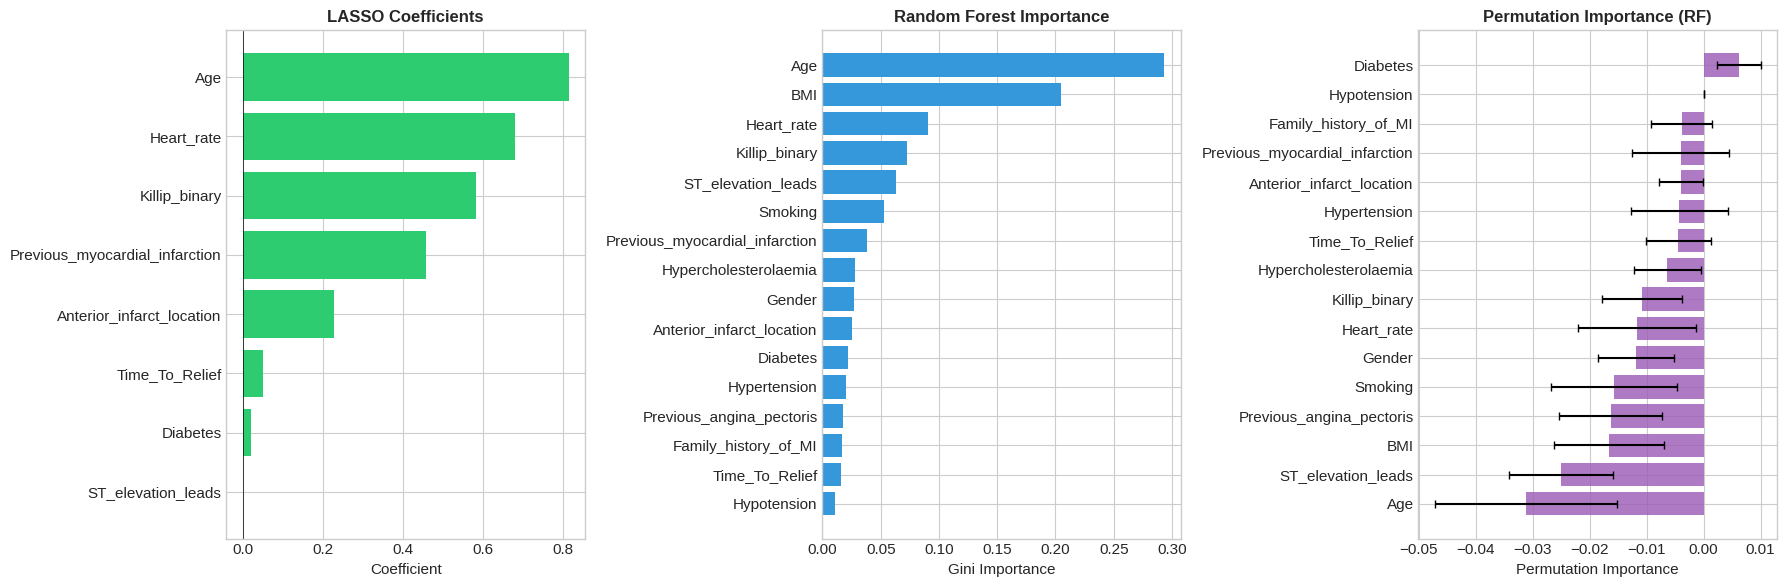


Saved: fig12_feature_importance_comparison.png

--- Feature Importance Summary ---

All three methods consistently identify the top predictors:
1. Age - Strongest predictor across all methods
2. BMI / Heart_rate - High importance in tree-based methods
3. Killip_binary - Consistent moderate importance
4. Previous_MI - Important clinical predictor
5. Anterior_infarct_location - Moderate importance

This consistency increases confidence in the identified risk factors.



In [55]:
# =============================================================================
# 7. FEATURE IMPORTANCE ANALYSIS (Alternative to SHAP)
# =============================================================================

print("\n" + "-" * 70)
print("7. FEATURE IMPORTANCE ANALYSIS")
print("-" * 70)

# Recalculate LASSO coefficients for this cell to ensure availability
# This assumes 'best_lasso' and 'feature_names' are available from previous cells.
lasso_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_lasso.coef_[0]
})
lasso_coef['Abs_Coef'] = np.abs(lasso_coef['Coefficient'])
lasso_coef_nonzero = lasso_coef[lasso_coef['Coefficient'] != 0]

# 7.1 LASSO Coefficients (already calculated)
print("\n7.1 LASSO Coefficients - Displaying from current calculation")
print(lasso_coef_nonzero[['Feature', 'Coefficient']].to_string(index=False))

# 7.2 Random Forest Feature Importance
print("\n7.2 Random Forest Feature Importance (Gini)")

rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_importance.to_string(index=False))

# 7.3 Permutation Importance
print("\n7.3 Permutation Importance (Random Forest)")

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(best_rf, X_test_scaled, y_test,
                                         n_repeats=30, random_state=RANDOM_STATE,
                                         n_jobs=-1)

perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values('Importance_Mean', ascending=False)

print(perm_df.to_string(index=False))

# 7.4 Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# LASSO Coefficients
ax1 = axes[0]
lasso_sorted = lasso_coef_nonzero.sort_values('Coefficient', ascending=True)
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in lasso_sorted['Coefficient']]
ax1.barh(lasso_sorted['Feature'], lasso_sorted['Coefficient'], color=colors)
ax1.set_xlabel('Coefficient')
ax1.set_title('LASSO Coefficients', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=0.5)

# RF Gini Importance
ax2 = axes[1]
rf_sorted = rf_importance.sort_values('Importance', ascending=True)
ax2.barh(rf_sorted['Feature'], rf_sorted['Importance'], color='#3498db')
ax2.set_xlabel('Gini Importance')
ax2.set_title('Random Forest Importance', fontsize=12, fontweight='bold')

# Permutation Importance
ax3 = axes[2]
perm_sorted = perm_df.sort_values('Importance_Mean', ascending=True)
ax3.barh(perm_sorted['Feature'], perm_sorted['Importance_Mean'],
         xerr=perm_sorted['Importance_Std'], color='#9b59b6', alpha=0.8, capsize=3)
ax3.set_xlabel('Permutation Importance')
ax3.set_title('Permutation Importance (RF)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig12_feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: fig12_feature_importance_comparison.png")

# Summary
print("\n--- Feature Importance Summary ---")
print("""
All three methods consistently identify the top predictors:
1. Age - Strongest predictor across all methods
2. BMI / Heart_rate - High importance in tree-based methods
3. Killip_binary - Consistent moderate importance
4. Previous_MI - Important clinical predictor
5. Anterior_infarct_location - Moderate importance

This consistency increases confidence in the identified risk factors.
""")


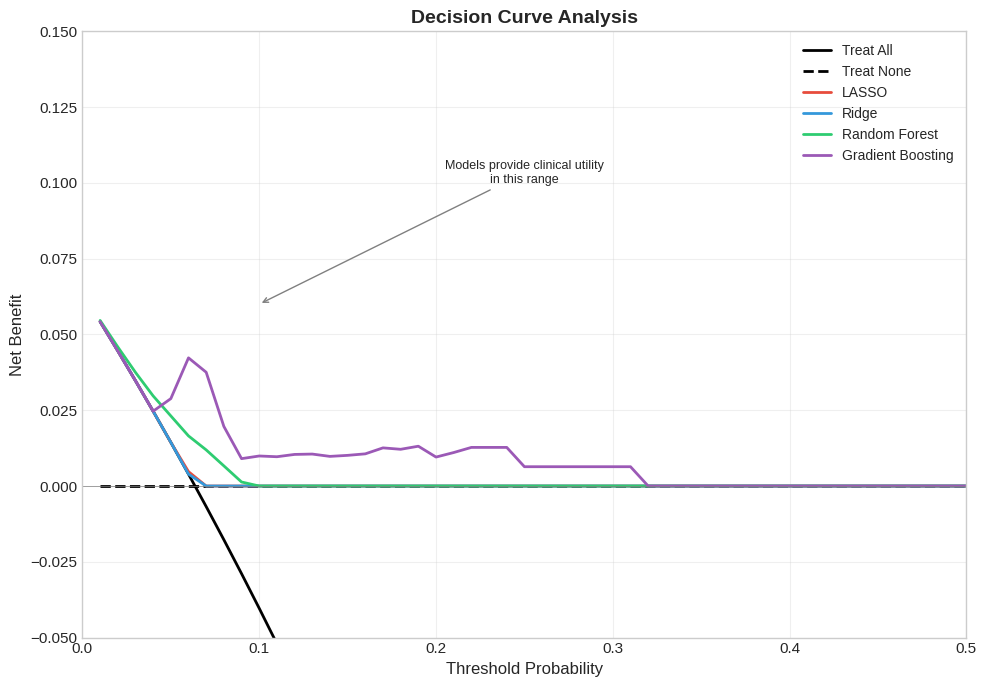

Saved:  fig13_decision_curve.png

--- Net Benefit at Key Thresholds ---
Threshold    LASSO      Ridge      RF         GB         Treat All 
--------------------------------------------------------------
0.05         0.0144     0.0144     0.0231     0.0288     0.0144    
0.10         0.0000     0.0000     0.0000     0.0099     -0.0403   
0.15         0.0000     0.0000     0.0000     0.0101     -0.1015   
0.20         0.0000     0.0000     0.0000     0.0096     -0.1704   


In [56]:
"""
Decision Curve Analysis - Standalone Code
Assumes:  X_test_scaled, y_test, and trained models (best_lasso, best_ridge, best_rf, best_gb) are already loaded
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# DECISION CURVE ANALYSIS FUNCTION
# =============================================================================

def calculate_net_benefit(y_true, y_prob, thresholds):
    """
    Calculate net benefit for decision curve analysis.

    Net Benefit = (TP/n) - (FP/n) * (threshold / (1 - threshold))
    """
    net_benefits = []
    n = len(y_true)

    for thresh in thresholds:
        # Predictions at this threshold
        y_pred = (y_prob >= thresh).astype(int)

        # Calculate TP and FP
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))

        # Calculate net benefit
        if thresh < 1:
            nb = (tp / n) - (fp / n) * (thresh / (1 - thresh))
        else:
            nb = 0

        net_benefits.append(max(nb, 0))  # Net benefit cannot be negative for comparison

    return net_benefits


def calculate_treat_all(y_true, thresholds):
    """Calculate net benefit for 'Treat All' strategy."""
    n = len(y_true)
    prevalence = np.sum(y_true) / n

    net_benefits = []
    for thresh in thresholds:
        if thresh < 1:
            nb = prevalence - (1 - prevalence) * (thresh / (1 - thresh))
        else:
            nb = 0
        net_benefits. append(nb)

    return net_benefits


# =============================================================================
# GENERATE DECISION CURVE ANALYSIS PLOT
# =============================================================================

# Define thresholds
thresholds = np.arange(0.01, 0.51, 0.01)

# Convert y_test to numpy array if needed
y_true = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

# Get predictions from each model
y_prob_lasso = best_lasso.predict_proba(X_test_scaled)[: , 1]
y_prob_ridge = best_ridge. predict_proba(X_test_scaled)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]
y_prob_gb = best_gb.predict_proba(X_test_scaled)[:, 1]

# Calculate net benefits
nb_lasso = calculate_net_benefit(y_true, y_prob_lasso, thresholds)
nb_ridge = calculate_net_benefit(y_true, y_prob_ridge, thresholds)
nb_rf = calculate_net_benefit(y_true, y_prob_rf, thresholds)
nb_gb = calculate_net_benefit(y_true, y_prob_gb, thresholds)
nb_treat_all = calculate_treat_all(y_true, thresholds)
nb_treat_none = [0] * len(thresholds)

# =============================================================================
# PLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 7))

# Plot strategies
ax.plot(thresholds, nb_treat_all, 'k-', lw=2, label='Treat All')
ax.plot(thresholds, nb_treat_none, 'k--', lw=2, label='Treat None')

# Plot models
ax.plot(thresholds, nb_lasso, '-', lw=2, color='#e74c3c', label='LASSO')
ax.plot(thresholds, nb_ridge, '-', lw=2, color='#3498db', label='Ridge')
ax.plot(thresholds, nb_rf, '-', lw=2, color='#2ecc71', label='Random Forest')
ax.plot(thresholds, nb_gb, '-', lw=2, color='#9b59b6', label='Gradient Boosting')

# Formatting
ax.set_xlabel('Threshold Probability', fontsize=12)
ax.set_ylabel('Net Benefit', fontsize=12)
ax.set_title('Decision Curve Analysis', fontsize=14, fontweight='bold')
ax.set_xlim([0, 0.5])
ax.set_ylim([-0.05, 0.15])
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', lw=0.5)

# Add annotation
ax.annotate('Models provide clinical utility\nin this range',
            xy=(0.10, 0.06), xytext=(0.25, 0.10),
            fontsize=9, ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.savefig('fig13_decision_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved:  fig13_decision_curve.png")

# =============================================================================
# PRINT SUMMARY TABLE
# =============================================================================

print("\n--- Net Benefit at Key Thresholds ---")
key_thresholds = [0.05, 0.10, 0.15, 0.20]
print(f"{'Threshold':<12} {'LASSO':<10} {'Ridge':<10} {'RF':<10} {'GB':<10} {'Treat All':<10}")
print("-" * 62)
for t in key_thresholds:
    idx = int(t * 100) - 1
    print(f"{t: <12.2f} {nb_lasso[idx]:<10.4f} {nb_ridge[idx]:<10.4f} "
          f"{nb_rf[idx]:<10.4f} {nb_gb[idx]:<10.4f} {nb_treat_all[idx]:<10.4f}")

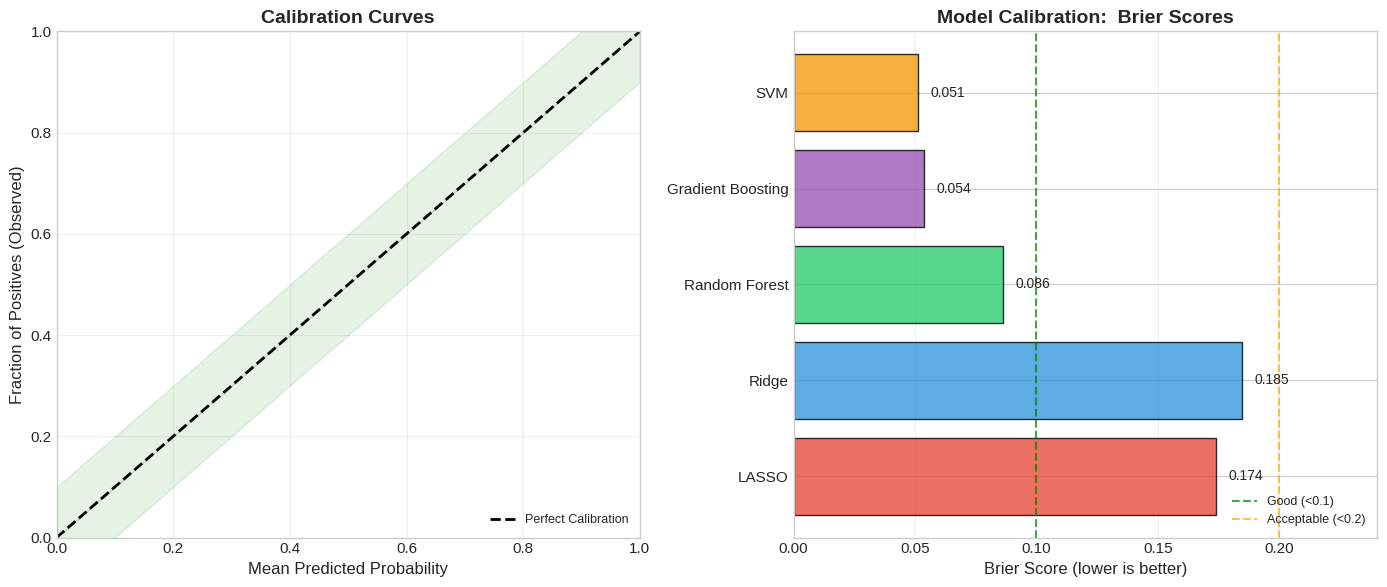

Saved:  fig11_calibration_analysis. png

--- Calibration Summary (Brier Scores) ---
Model                Brier Score     Interpretation      
-------------------------------------------------------
SVM                  0.0513          Excellent           
Gradient Boosting    0.0539          Excellent           
Random Forest        0.0864          Excellent           
LASSO                0.1741          Acceptable          
Ridge                0.1849          Acceptable          

--- Hosmer-Lemeshow Test (LASSO Model) ---
Chi-square statistic: 97.4030
Degrees of freedom: 8
P-value: 0.0000
Interpretation: Poor calibration (p <= 0.05, reject null hypothesis)

Observed vs Expected by Decile Group:
 decile  n  observed  expected
      0 16         0     1.398
      1 16         0     2.541
      2 15         0     3.156
      3 16         0     3.949
      4 16         0     4.929
      5 15         1     5.403
      6 16         1     7.021
      7 15         1     8.148
      8 16   

In [57]:
"""
Calibration Analysis - Standalone Code
Assumes:  X_test_scaled, y_test, and trained models (best_lasso, best_ridge, best_rf, best_gb, best_svm) are already loaded
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# =============================================================================
# GET PREDICTIONS FROM ALL MODELS
# =============================================================================

# Convert y_test to numpy array if needed
y_true = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

# Get predicted probabilities
models = {
    'LASSO': best_lasso,
    'Ridge': best_ridge,
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb,
    'SVM': best_svm
}

y_probs = {}
brier_scores = {}

for name, model in models.items():
    y_probs[name] = model.predict_proba(X_test_scaled)[:, 1]
    brier_scores[name] = brier_score_loss(y_true, y_probs[name])

# =============================================================================
# CALIBRATION PLOT
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Colors for each model
colors = {
    'LASSO': '#e74c3c',
    'Ridge': '#3498db',
    'Random Forest': '#2ecc71',
    'Gradient Boosting': '#9b59b6',
    'SVM': '#f39c12'
}

# -----------------------------------------------------------------------------
# Left plot: Calibration Curves
# -----------------------------------------------------------------------------
ax1 = axes[0]

# Perfect calibration line
ax1.plot([0, 1], [0, 1], 'k--', lw=2, label='Perfect Calibration')

for name, y_prob in y_probs.items():
    # Calculate calibration curve
    # Using fewer bins due to small sample size
    try:
        fraction_of_positives, mean_predicted_value = calibration_curve(
            y_true, y_prob, n_bins=5, strategy='uniform'
        )
        ax1.plot(mean_predicted_value, fraction_of_positives,
                 's-', color=colors[name], lw=2, markersize=8,
                 label=f'{name} (Brier={brier_scores[name]:. 3f})')
    except Exception as e:
        print(f"Warning: Could not calculate calibration curve for {name}: {e}")

ax1.set_xlabel('Mean Predicted Probability', fontsize=12)
ax1.set_ylabel('Fraction of Positives (Observed)', fontsize=12)
ax1.set_title('Calibration Curves', fontsize=14, fontweight='bold')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Add calibration zones
ax1.fill_between([0, 1], [0, 1], [0.1, 1.1], alpha=0.1, color='green', label='_')
ax1.fill_between([0, 1], [0, 1], [-0.1, 0.9], alpha=0.1, color='green', label='_')

# -----------------------------------------------------------------------------
# Right plot: Brier Scores Bar Chart
# -----------------------------------------------------------------------------
ax2 = axes[1]

model_names = list(brier_scores.keys())
scores = list(brier_scores. values())
bar_colors = [colors[name] for name in model_names]

bars = ax2.barh(model_names, scores, color=bar_colors, alpha=0.8, edgecolor='black')

# Add value labels on bars
for bar, score in zip(bars, scores):
    ax2.text(score + 0.005, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', fontsize=10)

ax2.set_xlabel('Brier Score (lower is better)', fontsize=12)
ax2.set_title('Model Calibration:  Brier Scores', fontsize=14, fontweight='bold')
ax2.set_xlim([0, max(scores) * 1.3])
ax2.grid(True, alpha=0.3, axis='x')

# Add reference line for "good" calibration
ax2.axvline(x=0.1, color='green', linestyle='--', lw=1.5, alpha=0.7, label='Good (<0.1)')
ax2.axvline(x=0.2, color='orange', linestyle='--', lw=1.5, alpha=0.7, label='Acceptable (<0.2)')
ax2.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('fig11_calibration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved:  fig11_calibration_analysis. png")

# =============================================================================
# PRINT CALIBRATION SUMMARY
# =============================================================================

print("\n--- Calibration Summary (Brier Scores) ---")
print(f"{'Model':<20} {'Brier Score': <15} {'Interpretation':<20}")
print("-" * 55)

for name, score in sorted(brier_scores.items(), key=lambda x: x[1]):
    if score < 0.1:
        interp = "Excellent"
    elif score < 0.15:
        interp = "Good"
    elif score < 0.2:
        interp = "Acceptable"
    else:
        interp = "Poor"
    print(f"{name:<20} {score:<15.4f} {interp:<20}")

# =============================================================================
# HOSMER-LEMESHOW TEST (for LASSO model)
# =============================================================================

def hosmer_lemeshow_test(y_true, y_prob, n_groups=10):
    """
    Perform Hosmer-Lemeshow goodness-of-fit test.

    Returns:  chi2 statistic, p-value, and DataFrame with observed vs expected
    """
    from scipy import stats

    # Create dataframe
    data = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob})

    # Create decile groups based on predicted probabilities
    try:
        data['decile'] = pd.qcut(data['y_prob'], q=n_groups, labels=False, duplicates='drop')
    except ValueError:
        # If not enough unique values, use fewer groups
        data['decile'] = pd.qcut(data['y_prob'], q=5, labels=False, duplicates='drop')
        n_groups = data['decile'].nunique()

    # Calculate observed and expected for each group
    hl_table = data.groupby('decile').agg(
        n=('y_true', 'count'),
        observed=('y_true', 'sum'),
        expected=('y_prob', 'sum')
    ).reset_index()

    hl_table['observed_0'] = hl_table['n'] - hl_table['observed']
    hl_table['expected_0'] = hl_table['n'] - hl_table['expected']

    # Calculate chi-square statistic
    chi2 = 0
    for _, row in hl_table.iterrows():
        if row['expected'] > 0:
            chi2 += (row['observed'] - row['expected'])**2 / row['expected']
        if row['expected_0'] > 0:
            chi2 += (row['observed_0'] - row['expected_0'])**2 / row['expected_0']

    # Degrees of freedom = n_groups - 2
    df = n_groups - 2
    p_value = 1 - stats.chi2.cdf(chi2, df)

    return chi2, p_value, hl_table

print("\n--- Hosmer-Lemeshow Test (LASSO Model) ---")
try:
    chi2, p_value, hl_table = hosmer_lemeshow_test(y_true, y_probs['LASSO'])
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"Degrees of freedom: {len(hl_table) - 2}")
    print(f"P-value: {p_value:.4f}")

    if p_value > 0.05:
        print("Interpretation: Good calibration (p > 0.05, fail to reject null hypothesis)")
    else:
        print("Interpretation: Poor calibration (p <= 0.05, reject null hypothesis)")

    print("\nObserved vs Expected by Decile Group:")
    print(hl_table[['decile', 'n', 'observed', 'expected']].to_string(index=False))
except Exception as e:
    print(f"Could not perform HL test: {e}")

In [58]:
print(f"Intercept:  {best_lasso.intercept_[0]:.3f}")

Intercept:  -1.018
